In [1]:
import os

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import seaborn as sns
from joblib import dump, load
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
# from xgboost import XGBRegressor 
# from lightgbm import LGBMRegressor

from dhi_mleo.inference import xr_predict
from dhi_mleo.plot import (
    corr_matrix, corr_target, 
    corr_bar, plot_loso_distributions, 
    plot_predictions_by_station
)
from dhi_mleo.stats import (
    evaluate_baseline, regression_metrics, 
    evaluate_stations, loso_cv_ml
)
from utils import preprocess_sensor_data

import warnings
warnings.filterwarnings('ignore')

# 1. Prepare the Data

Here we configure the dataset paths and choose which sensor data to use:
- A → only Sensor A
- B → only Sensor B
- AVG → if both sensors are available for a station, we take the average value.

> In our case, A and B are TDR sensors placed in the soil next to each other, so we opted to take the average to reduce sensor-specific noise and get a more representative soil moisture measurement.

In [2]:
# CONFIG
DATA_PATH_A = "../data/HOBE/hub/insitu/sm_features_sensor_typeA.csv"
DATA_PATH_B = "../data/HOBE/hub/insitu/sm_features_sensor_typeB.csv"
TARGET_COLUMN = "INSITU_SM"
SENSOR_OPTION = "AVG"   # "A" = only Sensor A, "B" = only Sensor B, "AVG" = average when both exist we take the avergae

In [3]:
df_A = pd.read_csv(DATA_PATH_A)
df_B = pd.read_csv(DATA_PATH_B)

data = preprocess_sensor_data(df_A=df_A, df_B=df_B, sensor_option=SENSOR_OPTION, target_column=TARGET_COLUMN)
data.drop(columns=['Unnamed: 0'], inplace=True)

In [4]:
data

,20_RZD,20_RZSM_band1,20_RZSM_band2,20_RZSM_band3,20_irri_calc,DOY_UTC,EA,ELEV,EMISS_C,EMISS_S,...,TSEB_PT_20_ET_day_gf_corr,TSEB_PT_20_LE_partition_gf_corr,TSEB_PT_20_flag_gf_corr,U,VZA,W_C,X_LAD,Land,Date,Station
0,0.300000,34.006161,26.765446,21.525434,0.0,1.0,8.252481,59.0,0.966979,0.973000,...,0.000000,NaN,400.0,10.580215,NaN,1.0,0.5,Heath,2018-01-01,1.01
1,0.300000,33.716316,26.985458,21.918430,0.0,1.0,8.243232,68.0,0.981119,0.973000,...,0.334450,0.000000,400.0,10.562121,NaN,1.0,0.5,Heath,2018-01-01,1.03
2,0.463173,NaN,NaN,NaN,0.0,1.0,8.224812,89.0,0.983283,0.973000,...,0.000000,NaN,103.0,10.250333,NaN,2.0,1.0,Forest,2018-01-01,1.04
3,0.419346,NaN,NaN,NaN,0.0,1.0,8.233493,77.0,0.971019,0.973000,...,0.000000,NaN,101.0,10.521594,NaN,2.0,1.0,Forest,2018-01-01,1.05
4,0.365044,46.726318,44.237488,59.932663,0.0,1.0,8.258255,60.0,0.966696,0.973000,...,0.340658,0.000000,400.0,10.482258,NaN,1.0,0.5,Agriculture,2018-01-01,1.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10215,0.611132,27.715672,27.297747,22.452106,0.0,365.0,9.742756,38.0,0.943120,0.973000,...,0.022057,0.420406,400.0,7.161457,NaN,1.0,0.5,Agriculture,2018-12-31,3.05
10216,0.460296,NaN,NaN,NaN,0.0,365.0,9.724495,39.0,0.938052,0.973000,...,0.000000,NaN,101.0,7.177965,NaN,2.0,1.0,Forest,2018-12-31,3.06
10217,0.300000,47.091751,58.689762,91.602402,0.0,365.0,9.728883,26.0,0.976801,0.975423,...,0.276231,0.000000,400.0,7.190635,NaN,1.0,0.5,Agriculture,2018-12-31,3.07
10218,0.754912,29.415861,29.765877,25.656578,0.0,365.0,9.802838,89.0,0.958730,0.973000,...,0.000000,NaN,400.0,7.259741,NaN,1.0,0.5,Agriculture,2018-12-31,3.08


In [5]:
data["Date"] = pd.to_datetime(data["Date"]) 
data['Month'] = data['Date'].dt.month
SM_S2_BANDS = {
    'REFL_band1': "B2",
    'REFL_band2': "B3",
    'REFL_band3': "B4",
    'REFL_band4': "B5",
    'REFL_band5': "B6",
    'REFL_band6': "B7",
    'REFL_band7': "B8A",
    'REFL_band8': "B11",
    'REFL_band9': "B12"
}
data = data.rename(columns=SM_S2_BANDS)

- Lets inpect the spatial locations of the sensors

In [6]:
geos = data[["Station", "LAT", "LON", "Land"]].drop_duplicates()
gdf_stations = gpd.GeoDataFrame(
    geos, geometry=gpd.points_from_xy(geos.LON, geos.LAT), crs="EPSG:4326"
)

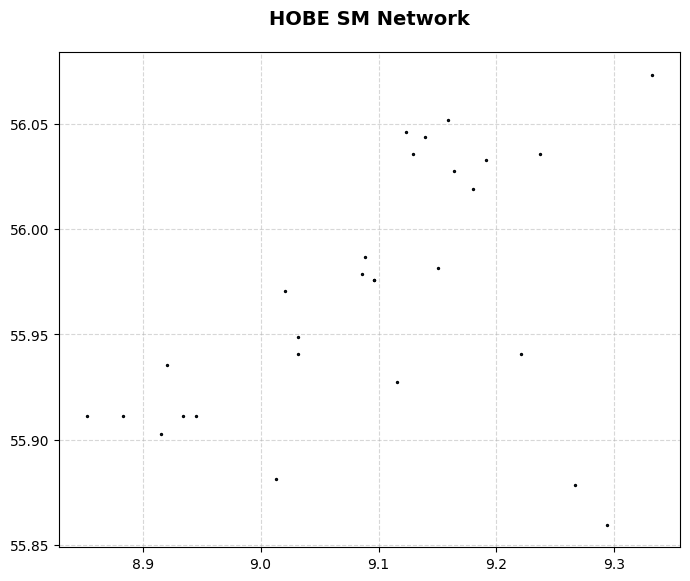

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))

gdf_stations.plot(
    ax=ax,
    marker='o',
    color='dodgerblue',
    edgecolor='black',
    markersize=2,
    label='Stations'
)
ax.set_title('HOBE SM Network', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

- In case of issues with leaflet in vs code https://github.com/microsoft/vscode-jupyter/issues/16008#issuecomment-2336541224

In [8]:
gdf_stations.explore()

### 1.1. Add Spectral indices related to SM and our Modelled SM

- **NDVI**: Normalized Difference Vegetation Index
- **MNDWI**: Modified Normalized Difference Water Index 
- **NMDI**: Normalized Multi-band Drought Index 
- **PSRI**: Plant Senescence Reflectance Index
- **VARI_red_edge**: Visible Atmospherically Resistant Index
- **BSI**: Bare Soil Index (BSI)

In [9]:
data['INSITU_SM'] = data['INSITU_SM'] * 100
data['weighted_sm'] = (data['20_RZSM_band1'] + data['20_RZSM_band2']) / 2

data['NDVI'] = (data["B8A"] - data["B4"]) / (data["B8A"] + data["B4"])
data['MNDWI'] = (data["B3"] - data["B11"]) / (data["B3"] + data["B11"])
data['NMDI'] =  (data["B8A"] - (data["B11"] - data["B12"])) / (data["B8A"] + (data["B11"] - data["B12"]))
data["PSRI"] = (data["B4"] - data["B2"]) / (data["B8A"])
data["VARI_red_edge"] = (data["B5"] - (1.7 * data["B4"]) + (0.7 * data["B2"])) / (data["B5"] + (2.3 * data["B4"]) - (1.3 * data["B2"]))
data["BSI"] = ((data["B11"] + data["B4"]) - (data["B8A"] + data["B2"])) / ((data["B11"] + data["B4"]) + (data["B8A"] + data["B2"]))

- Quick descriptive statistics for few variables

In [10]:
data.iloc[:,-6:].describe()

,NDVI,MNDWI,NMDI,PSRI,VARI_red_edge,BSI
count,9140.000000,9140.000000,9140.000000,9140.000000,9140.000000,9140.000000
mean,0.551985,-0.397963,0.654514,0.062557,-0.103933,-0.127476
std,0.226092,0.275415,0.156454,0.108749,32.357169,0.218539
min,0.003751,-0.996383,0.262496,-2.013333,-3093.117984,-0.893130
25%,0.372788,-0.561777,0.547394,0.006893,0.058427,-0.308374
50%,0.562417,-0.485827,0.651651,0.055240,0.173367,-0.110774
75%,0.756609,-0.355347,0.741482,0.122846,0.358368,0.054806
max,0.998541,0.759206,1.236287,0.381783,6.106381,0.409978


In [11]:
data[["INSITU_SM", "weighted_sm"]].describe()

,INSITU_SM,weighted_sm
count,6546.000000,8760.000000
mean,19.337296,27.501011
std,10.454520,9.427447
min,0.100000,7.700000
25%,11.723958,23.635492
50%,18.250000,26.673350
75%,24.474479,30.538210
max,82.387500,57.815874


# 2. Data Exploration

### 2.1. How much valid data/nodata do we have ?
- Lets keep only the data where the INSITU SM is available
- We will also ignore the data where the type of the Land is "Forest" because we would like to use the data for moddeling SM over agriculture areas (Health land will also be considered)

In [12]:
LANDCOVER_EXCLUDE = ["Forest"] 

df_non_missing_target = data[data['INSITU_SM'].notna()]
excluded_stations = df_non_missing_target[df_non_missing_target["Land"].isin(LANDCOVER_EXCLUDE)]["Station"].unique()
df_filtered = df_non_missing_target[~df_non_missing_target["Station"].isin(excluded_stations)]
print("Final dataset shape:", df_filtered.shape)

Final dataset shape: (5329, 87)


In [13]:
# Dataset-level NaN stats
n_nan_rows = df_filtered[df_filtered.isna().any(axis=1)].shape[0]
n_total_rows = len(df_filtered)
nan_percentage = (n_nan_rows / n_total_rows) * 100
valid_percentage = 100 - nan_percentage

print(f"Percentage of valid data: {valid_percentage:.2f}%")
print(f"Percentage of NaN data: {nan_percentage:.2f}%")

Percentage of valid data: 16.08%
Percentage of NaN data: 83.92%


In [14]:
variable_stats = []

for col in df_filtered.columns:
    n_nan = df_filtered[col].isna().sum()
    total = len(df_filtered)
    nan_pct = (n_nan / total) * 100
    valid_pct = 100 - nan_pct

    variable_stats.append({
        'Variable': col,
        'Total_Rows': total,
        'NaN_Rows': n_nan,
        'Valid_Percentage': valid_pct,
        'NaN_Percentage': nan_pct
    })

df_variable_stats = pd.DataFrame(variable_stats).sort_values(by='Valid_Percentage', ascending=False)

In [15]:
df_variable_stats

,Variable,Total_Rows,NaN_Rows,Valid_Percentage,NaN_Percentage
0,20_RZD,5329,0,100.000000,0.000000
1,20_RZSM_band1,5329,0,100.000000,0.000000
2,20_RZSM_band2,5329,0,100.000000,0.000000
3,20_RZSM_band3,5329,0,100.000000,0.000000
13,F_C,5329,0,100.000000,0.000000
...,...,...,...,...,...
28,PT_20_CWSI,5329,4072,23.587915,76.412085
46,PT_20_delta_R_n1,5329,4072,23.587915,76.412085
41,PT_20_R_n1,5329,4072,23.587915,76.412085
39,PT_20_LE_partition,5329,4240,20.435354,79.564646


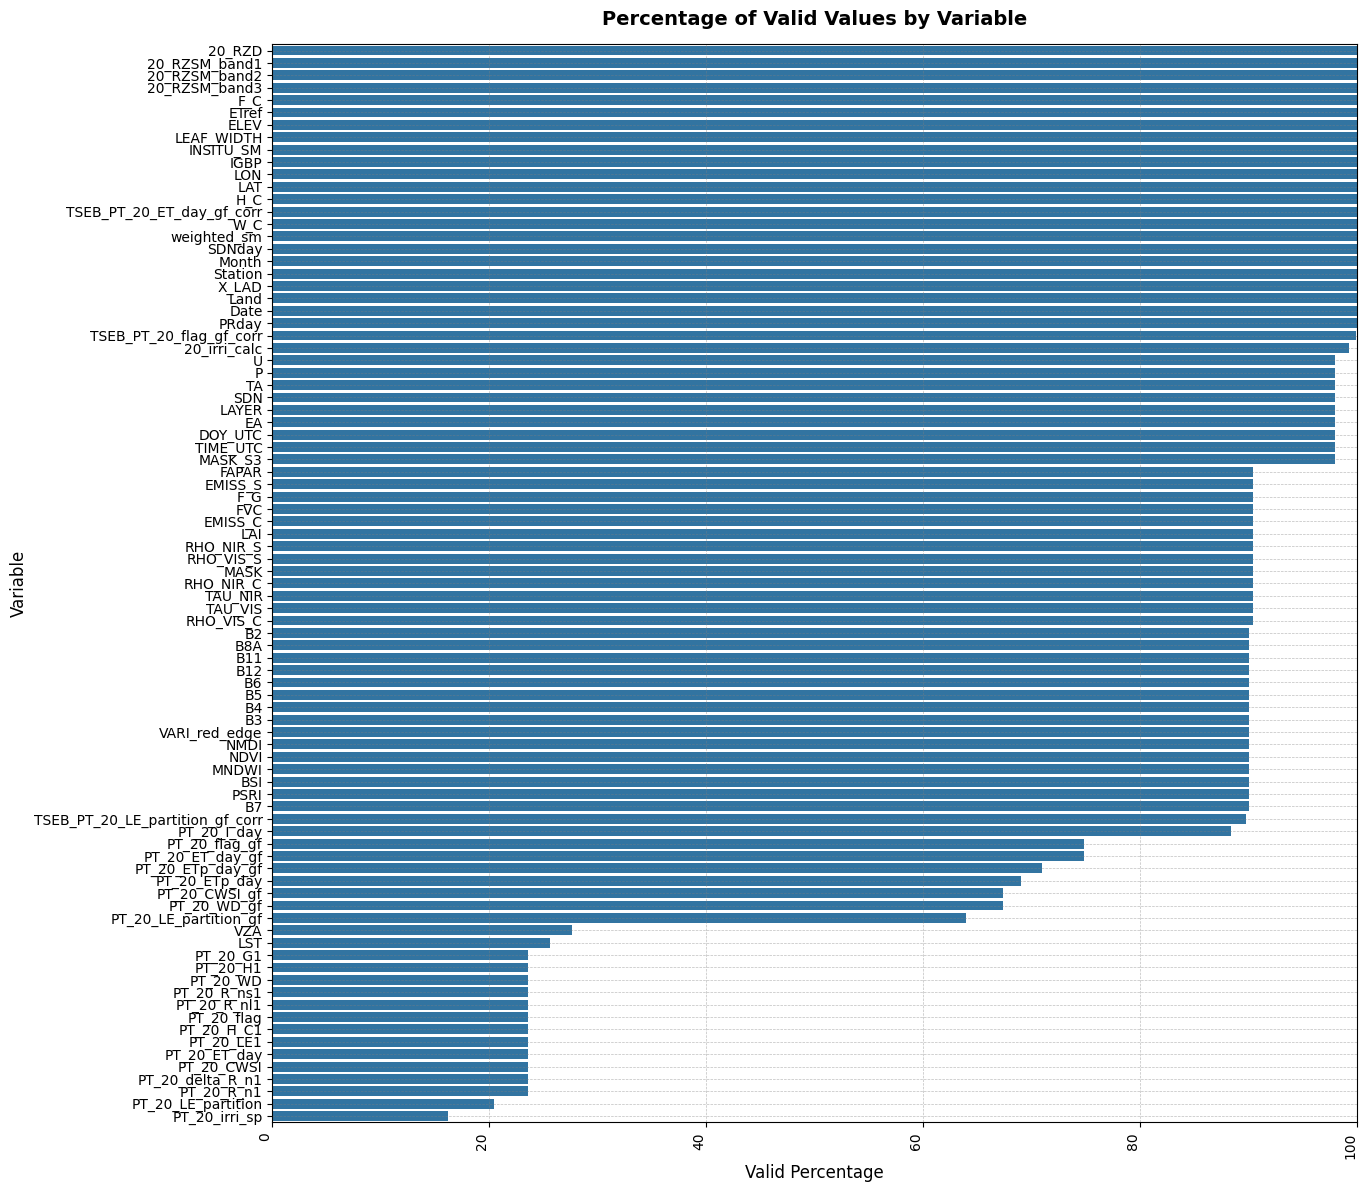

In [16]:
stats_df_sorted = df_variable_stats.sort_values(by='Valid_Percentage', ascending=False)

plt.figure(figsize=(14, 14))

sns.barplot(y='Variable', x='Valid_Percentage', data=stats_df_sorted)
plt.title('Percentage of Valid Values by Variable', size=14, weight='bold', pad=14)
plt.xlabel('Valid Percentage', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.xlim([0, 100])
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.show()

### 2.2. Time Series (TS) Exploration

- Lets plot SM TS accross all stations and compare it with our produced DHI SM at 10cm. 

In [17]:
SM_TYPE = "weighted_sm" # or 20_RZSM_band1 	20_RZSM_band2 	20_RZSM_band3

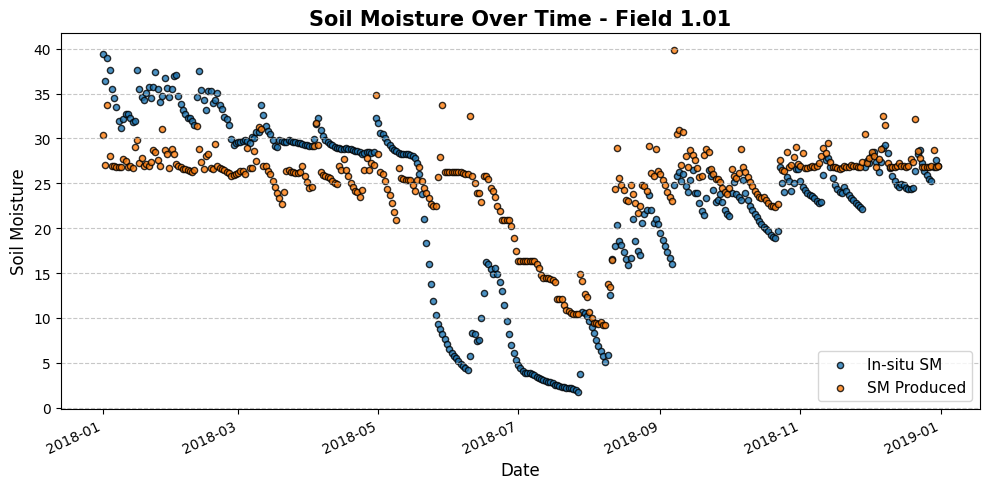

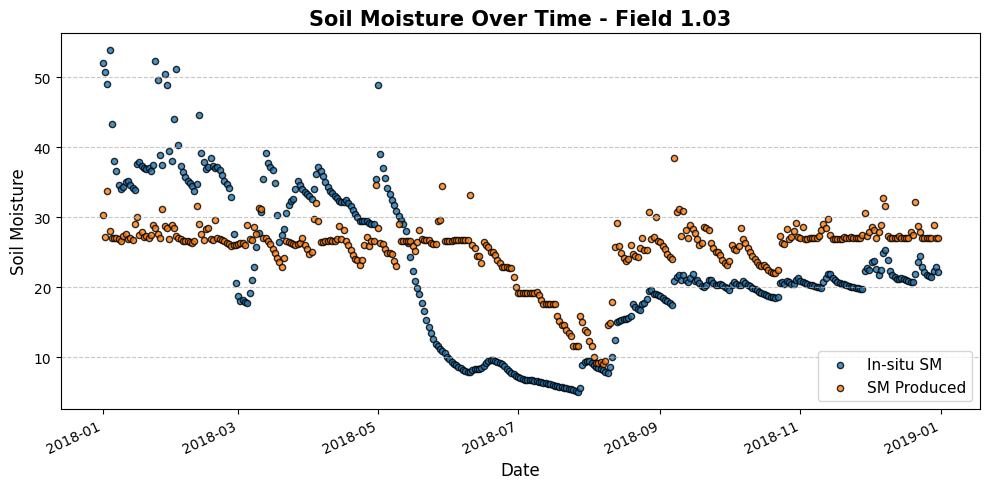

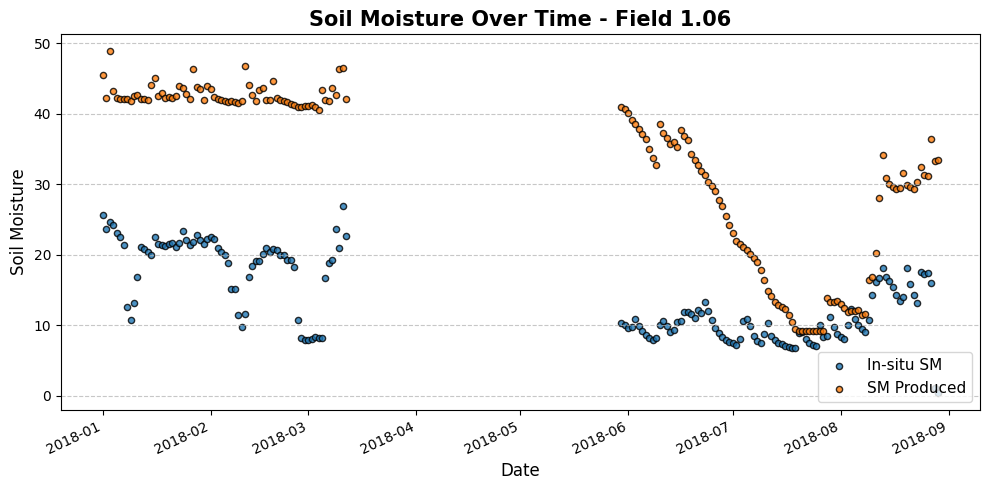

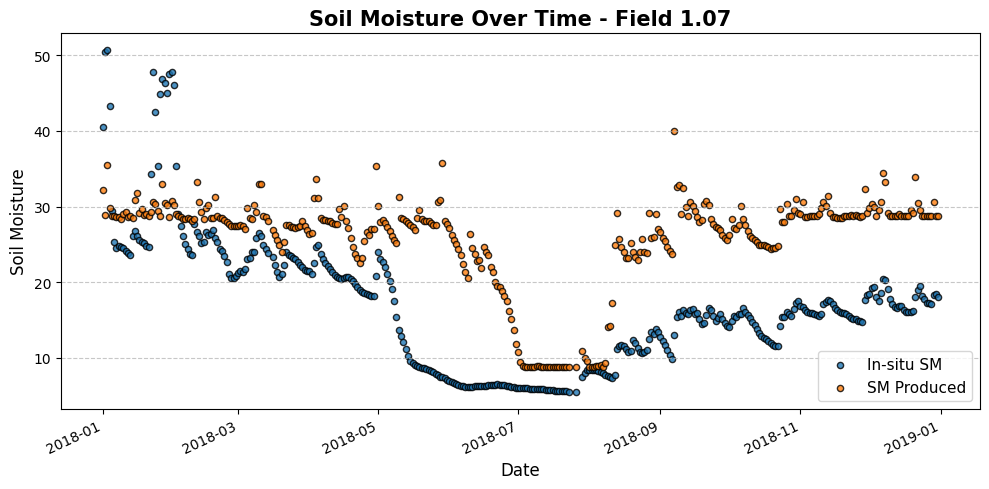

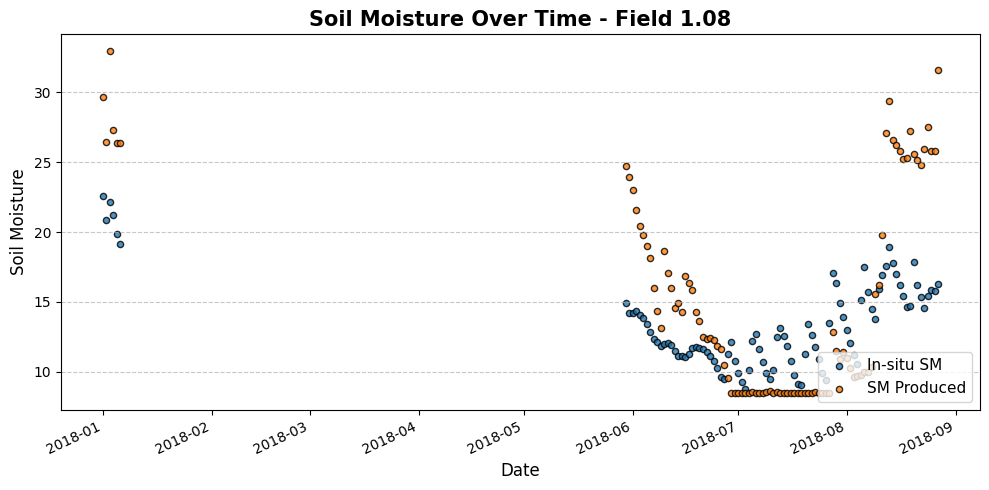

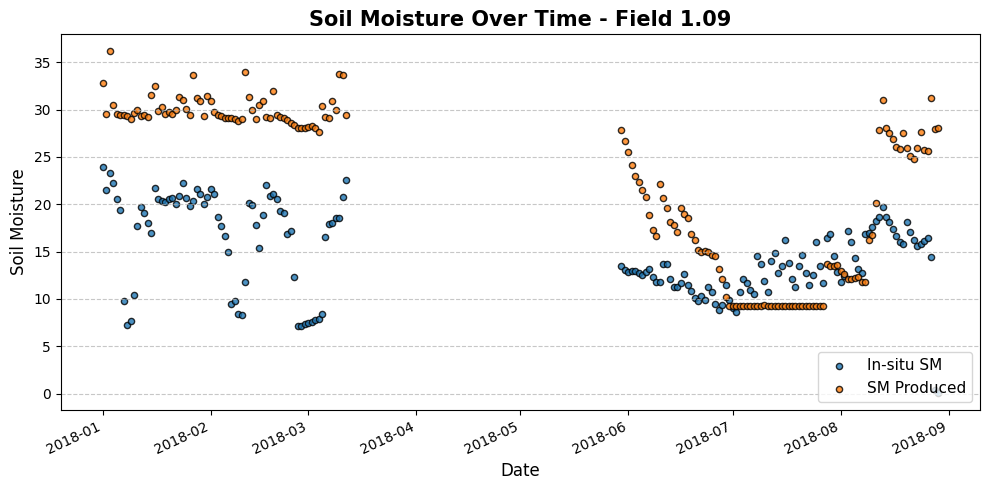

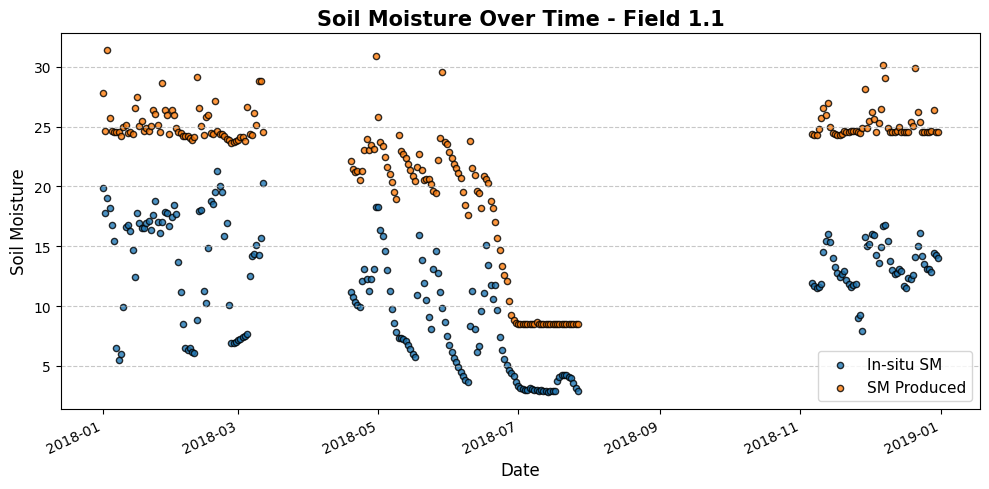

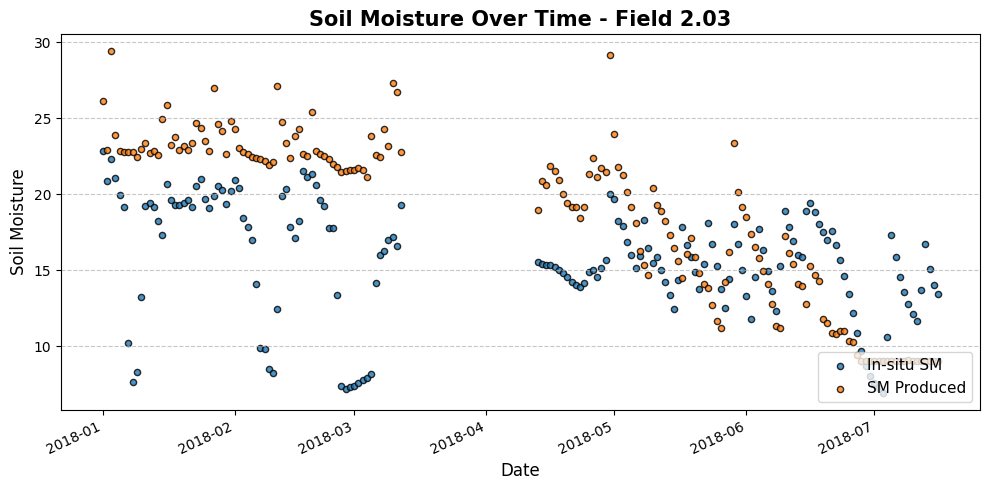

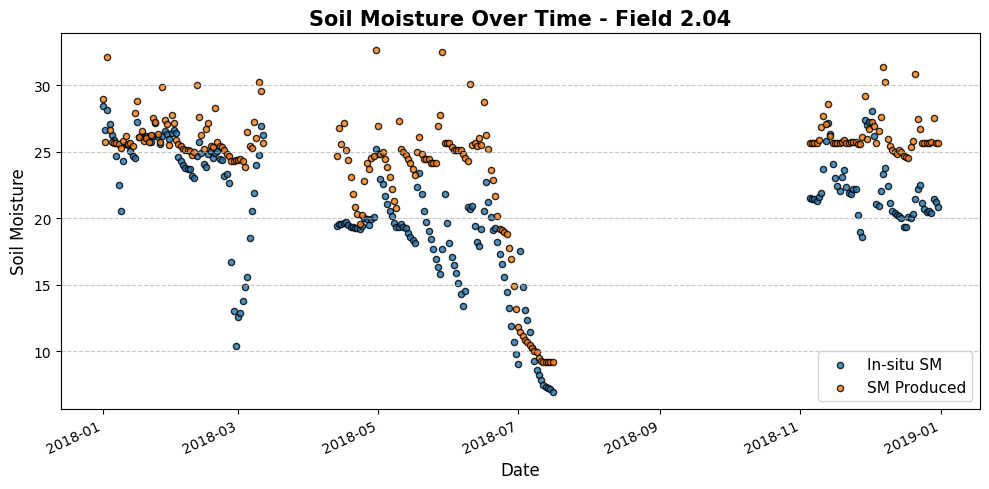

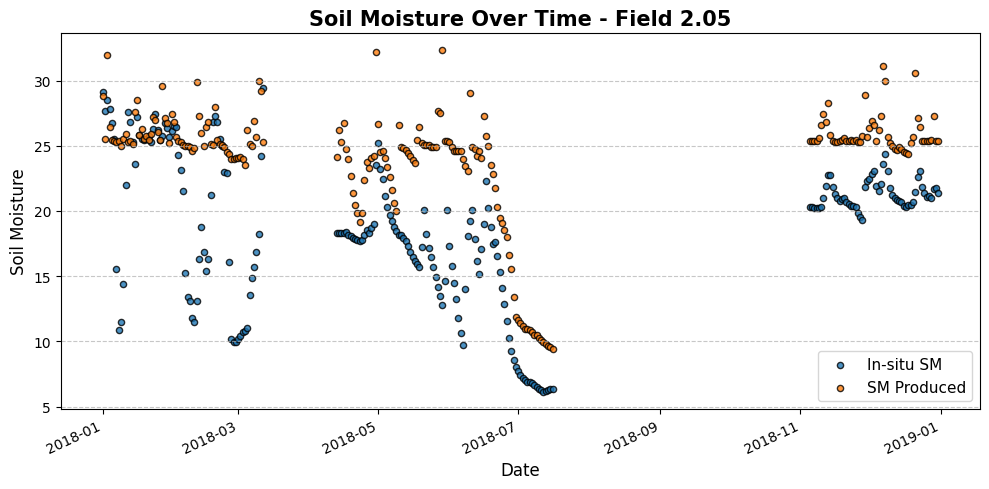

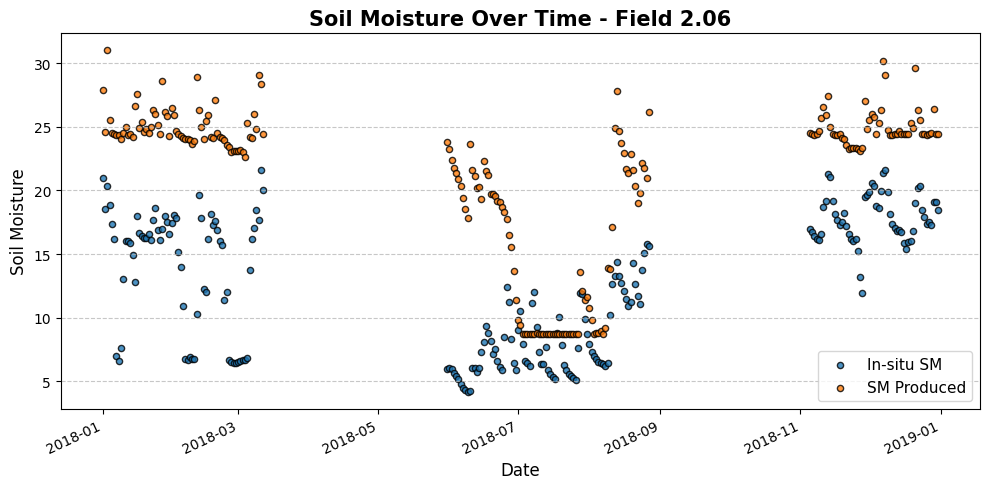

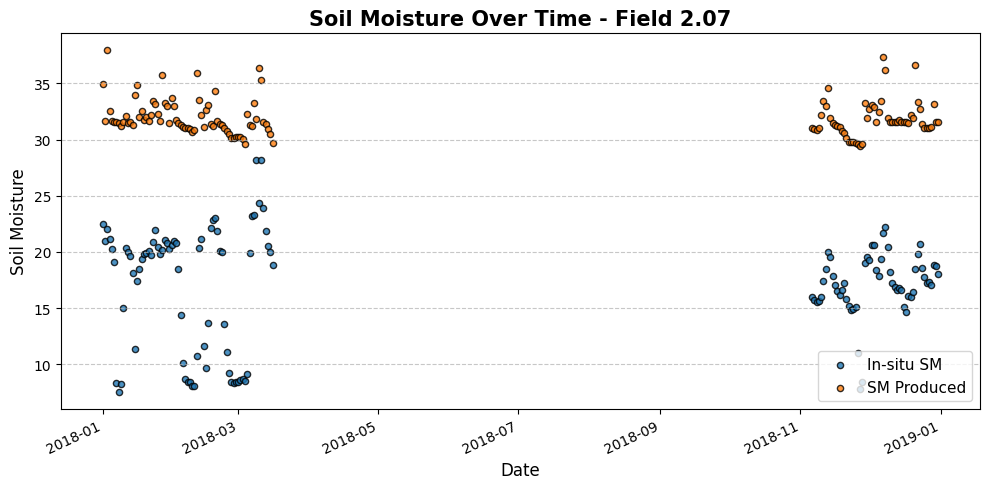

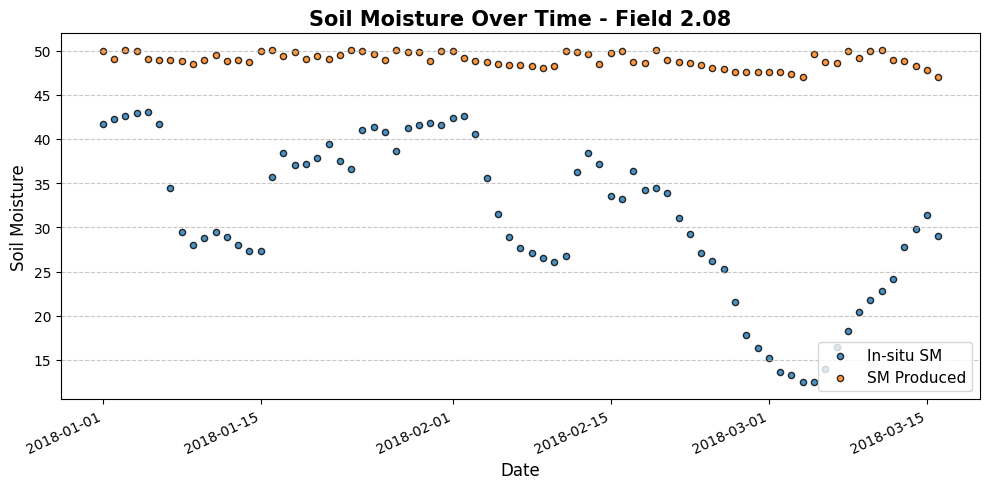

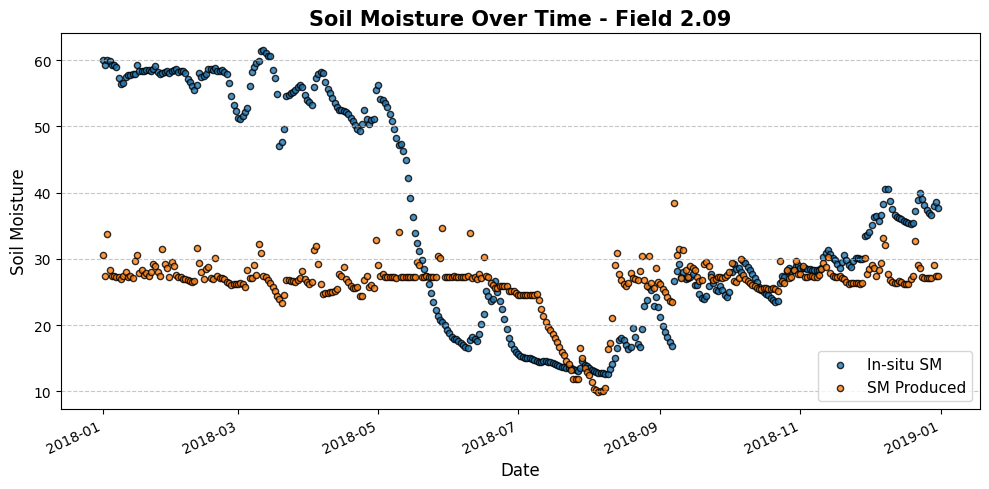

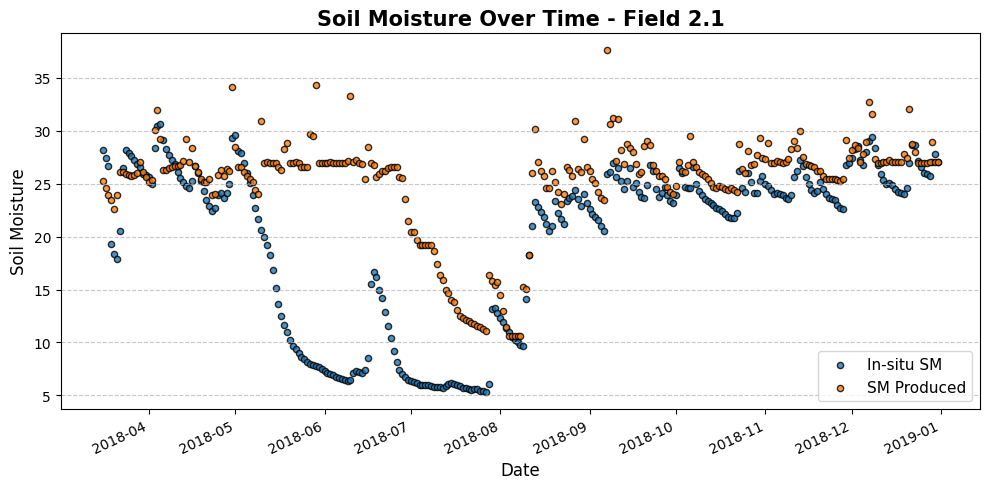

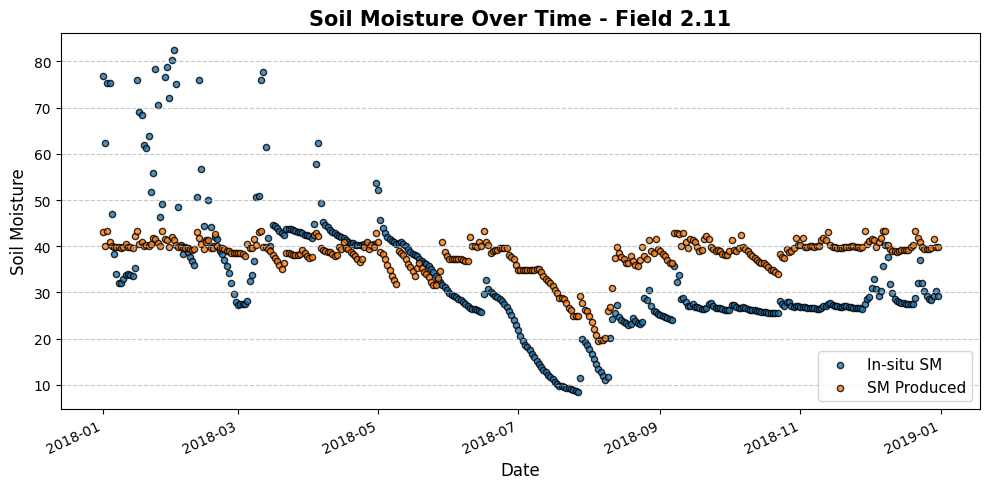

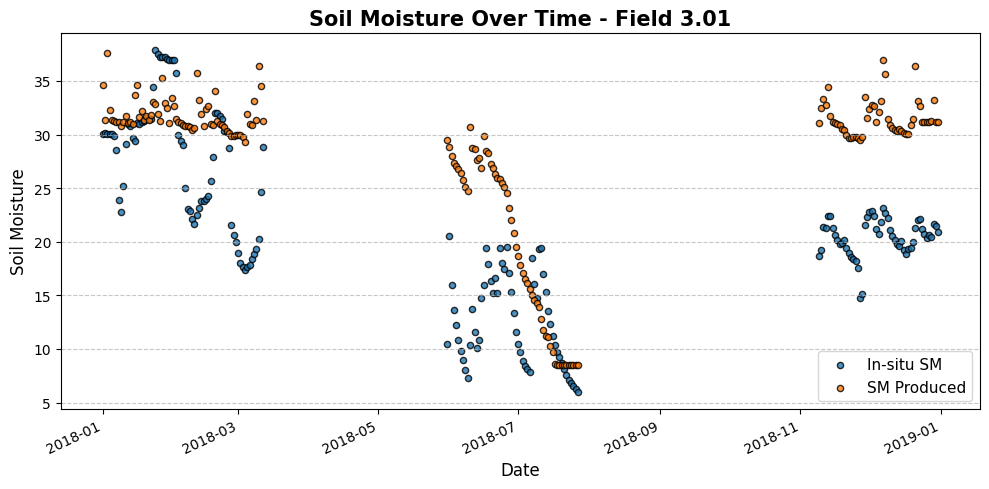

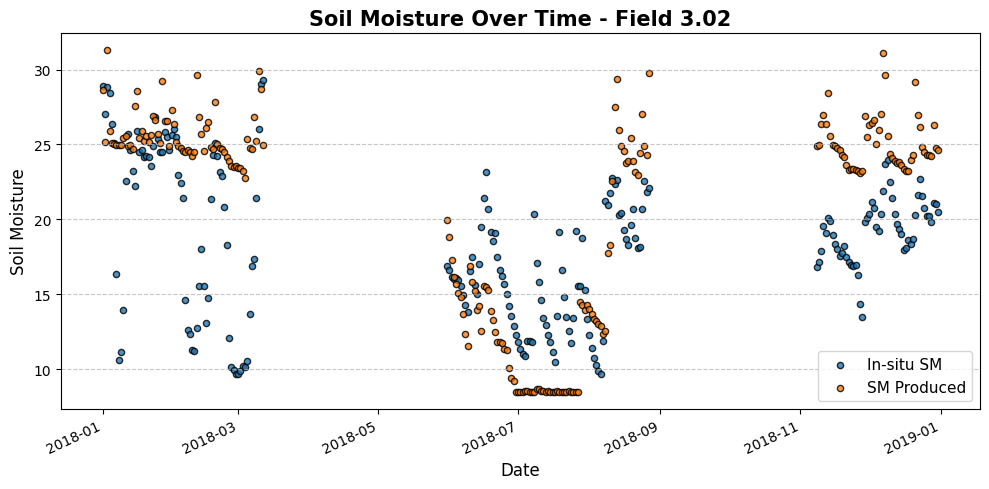

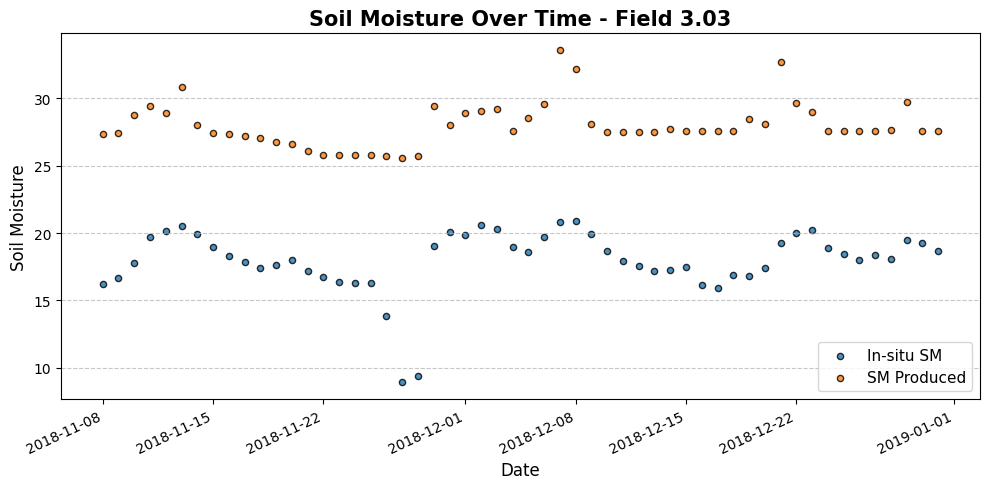

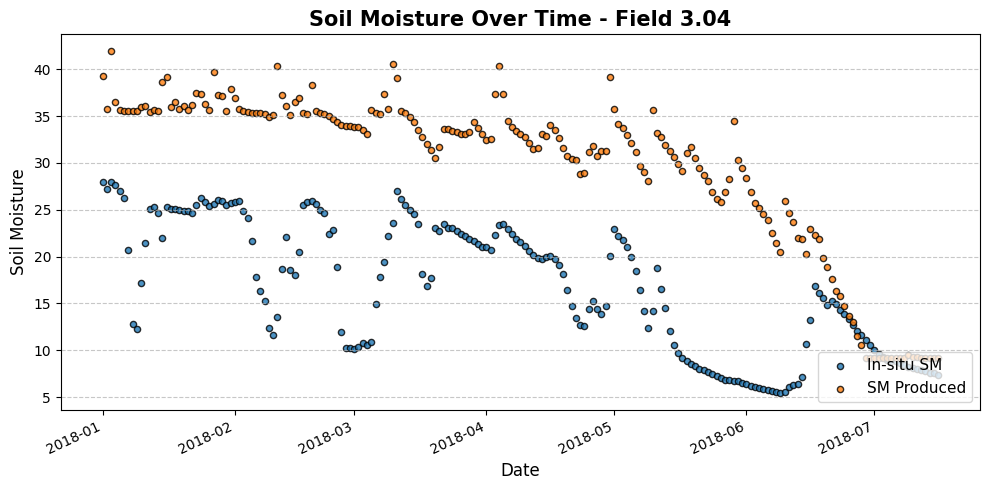

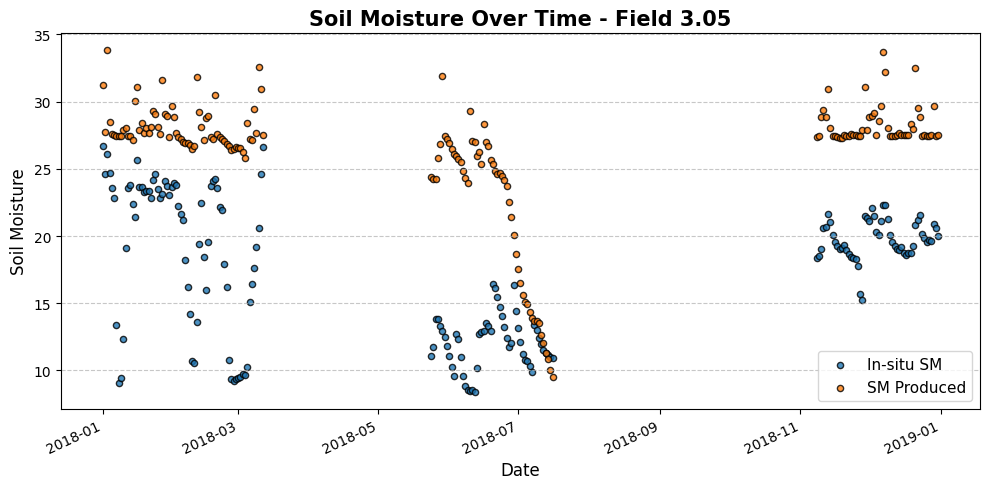

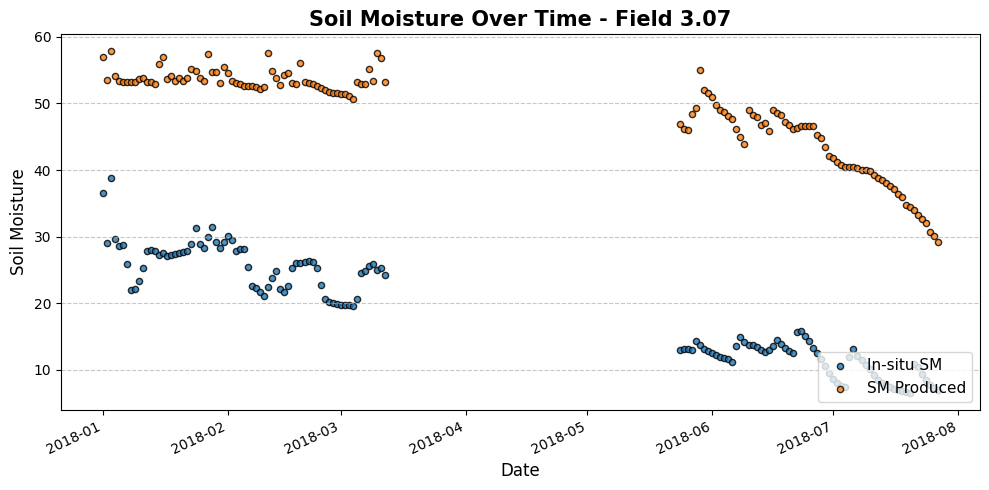

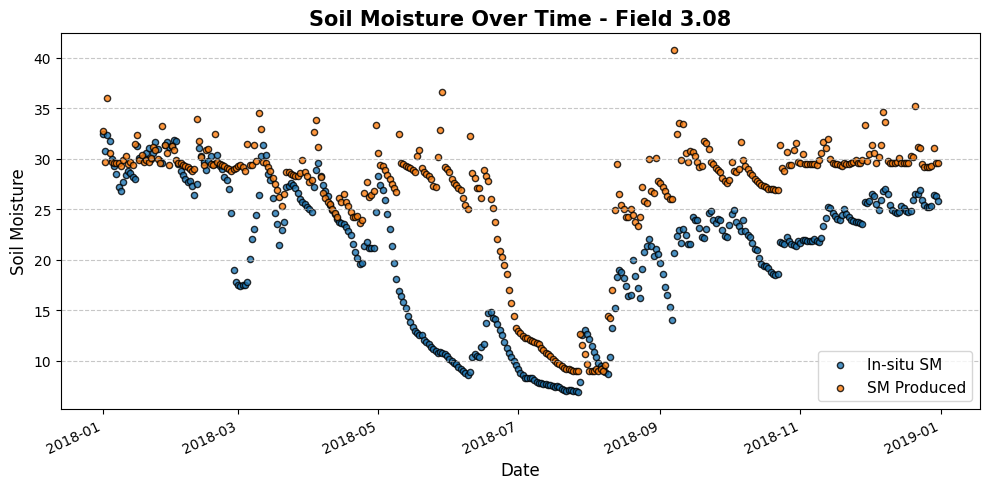

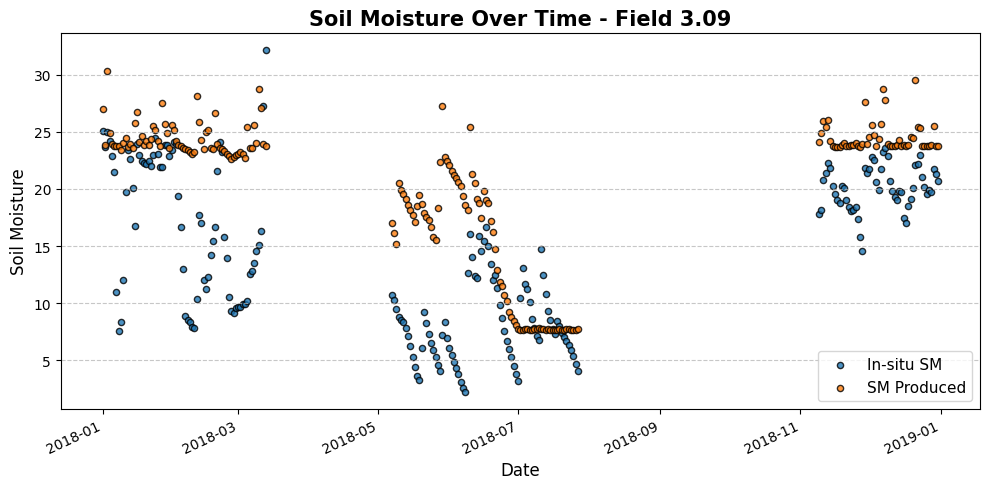

In [18]:
for field_id in np.unique(df_filtered['Station']):
    fig, ax = plt.subplots(figsize=(10, 5)) 

    df_st = df_filtered[df_filtered['Station'] == field_id]
    
    ax.scatter(df_st["Date"], df_st['INSITU_SM'], 
               label='In-situ SM', s=20, color='tab:blue', marker='o', edgecolor='k', alpha=0.8)
    ax.scatter(df_st["Date"], df_st[f'{SM_TYPE}'], 
               label='SM Produced', s=20, color='tab:orange', marker='o', edgecolor='k', alpha=0.8)

    ax.set_title(f'Soil Moisture Over Time - Field {field_id}', fontsize=15, weight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Soil Moisture', fontsize=12)
    
    ax.legend(loc='lower right', fontsize=11, frameon=True)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    fig.autofmt_xdate(rotation=25)
    plt.tight_layout()
    plt.show()

- Let's examine the distribution of soil moisture (SM) in comparison to our derived topsoil SM estimates.

In [19]:
df_long = pd.melt(
    df_filtered,
    id_vars=["Station"], 
    value_vars=["INSITU_SM", SM_TYPE], 
    var_name="Source", 
    value_name="Soil_Moisture"
)

In [20]:
df_long

,Station,Source,Soil_Moisture
0,1.01,INSITU_SM,39.431250
1,1.03,INSITU_SM,52.093478
2,1.06,INSITU_SM,25.695833
3,1.07,INSITU_SM,40.550000
4,1.08,INSITU_SM,22.610417
...,...,...,...
10653,3.02,weighted_sm,24.645606
10654,3.03,weighted_sm,27.581972
10655,3.05,weighted_sm,27.506709
10656,3.08,weighted_sm,29.590869


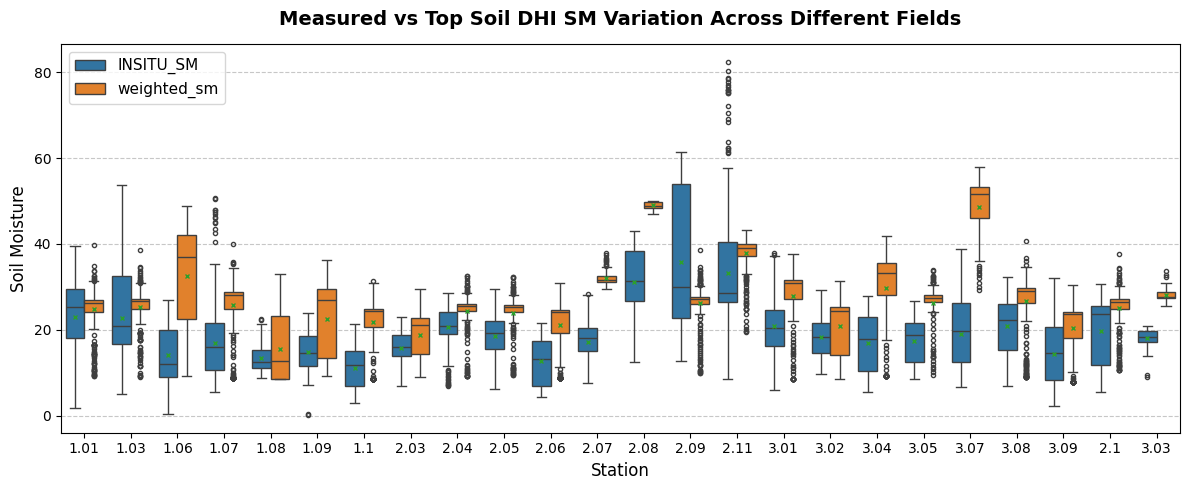

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))  

palette = {"INSITU_SM": "tab:blue", "weighted_sm": "tab:orange"}

sns.boxplot(
    x="Station", 
    y="Soil_Moisture", 
    hue="Source",  
    data=df_long, 
    palette=palette,
    showmeans=True, 
    showfliers=True,
    fliersize=3, 
    meanprops={
        "marker": "x",
        "markersize": 3, 
        "markerfacecolor": "tab:green", 
        "markeredgecolor": "tab:green"
    },
    ax=ax
)
#fig.autofmt_xdate(rotation=25)
ax.set_title("Measured vs Top Soil DHI SM Variation Across Different Fields", 
             size=14, weight='bold', pad=14)
ax.set_xlabel("Station", fontsize=12)
ax.set_ylabel("Soil Moisture", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='upper left', fontsize=11, frameon=True, title_fontsize=12)
plt.tight_layout()
plt.show()

> Overall, our predicted soil moisture generally overestimates the true values, except at station 2.09. This is true in both boxplots and the time series plots, although the latter show that main temporal trends are captured quite well.

# 3. Feature Exploration

- We’ll examine selected predictor variables. (Note: Consider using RFECV for automated feature selection in the future.)
- The data will also be split into training and test sets based on time intervals to prevent [data leakage](https://en.wikipedia.org/wiki/Leakage_(machine_learning)).

In [22]:
df_valid_train = df_filtered[df_filtered.Date < "2018-07-01"]
df_valid_test =  df_filtered[(df_filtered['Date'] >= "2018-07-01") & (df_filtered['Date'] <= "2019-01-01")]

- LAI: Leaf Area Index
- ETref: Reference Evapotranspiration
- EA: Air Humidity
- P: Air Pressure
- FAPAR Fraction of Absorbed Photosynthetically Active Radiation
- PT_20_ETp_day_gf: Potential ET gap-filled

In [23]:
to_keep = [
    'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8A', 'B11', 'B12',
    'MNDWI', 'NMDI', 'PSRI', 'VARI_red_edge', 'BSI', 
    'ELEV', 
    "TSEB_PT_20_ET_day_gf_corr", "LAI", "ETref", "EA", "P", "PT_20_WD_gf", 
    "weighted_sm", "20_RZSM_band1", 
    "FAPAR", "TAU_NIR", "PT_20_ETp_day_gf", 
    "Month", "DOY_UTC"
]

X_train = df_valid_train[to_keep]
y_train = df_valid_train[["INSITU_SM"]]

X_test = df_valid_test[to_keep]
y_test = df_valid_test[["INSITU_SM"]]

In [24]:
numeric_data = df_valid_train[to_keep + ["INSITU_SM"]].select_dtypes(include=[np.number])

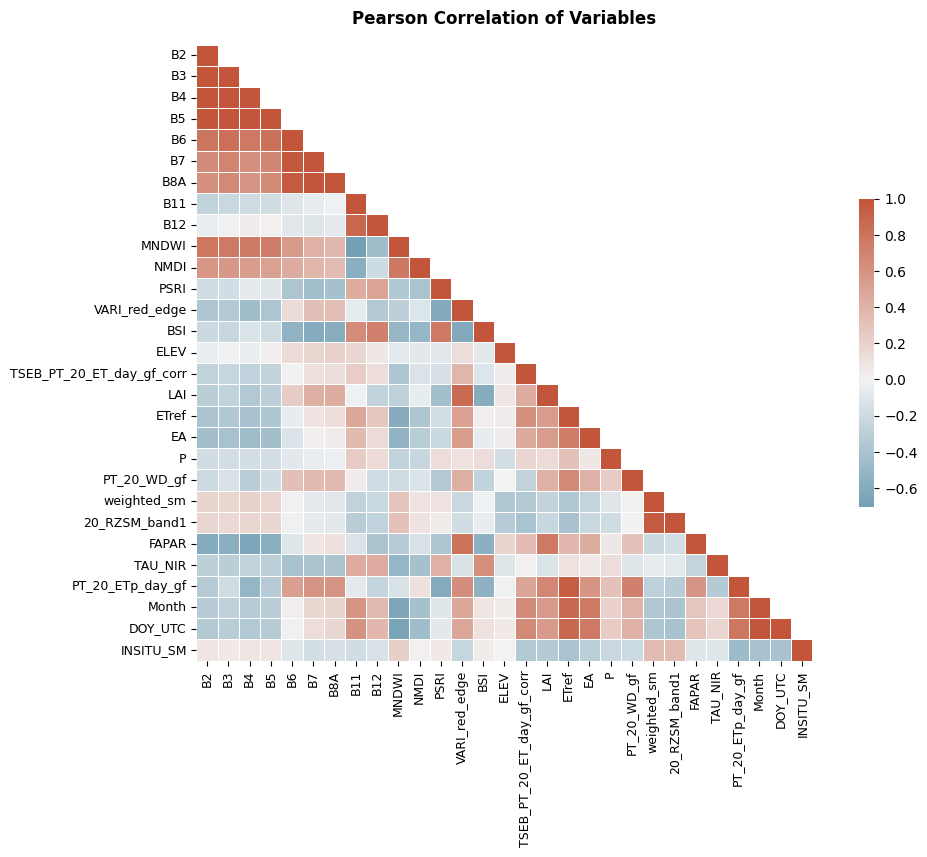

In [25]:
# Correlation matrix
corr_matrix(numeric_data, title="Pearson Correlation of Variables")
plt.show()

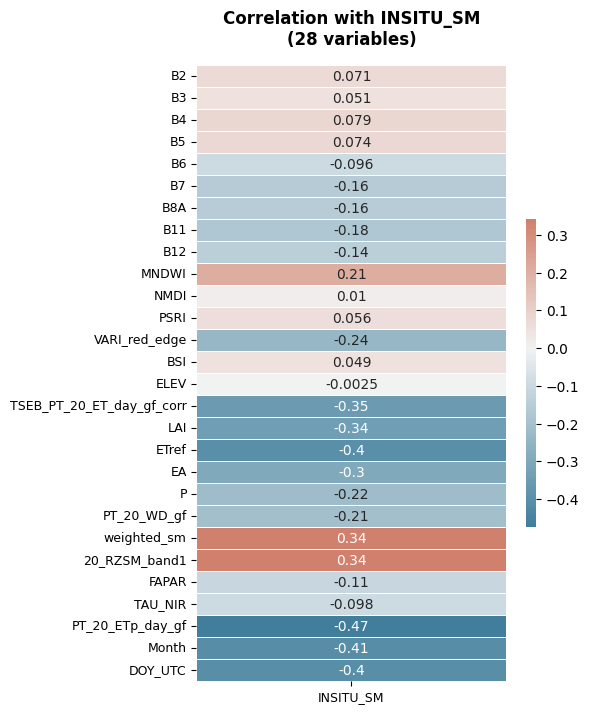

In [26]:
# correlation with SM
corr_target(numeric_data, target="INSITU_SM", figsize=(5,8))
plt.show()

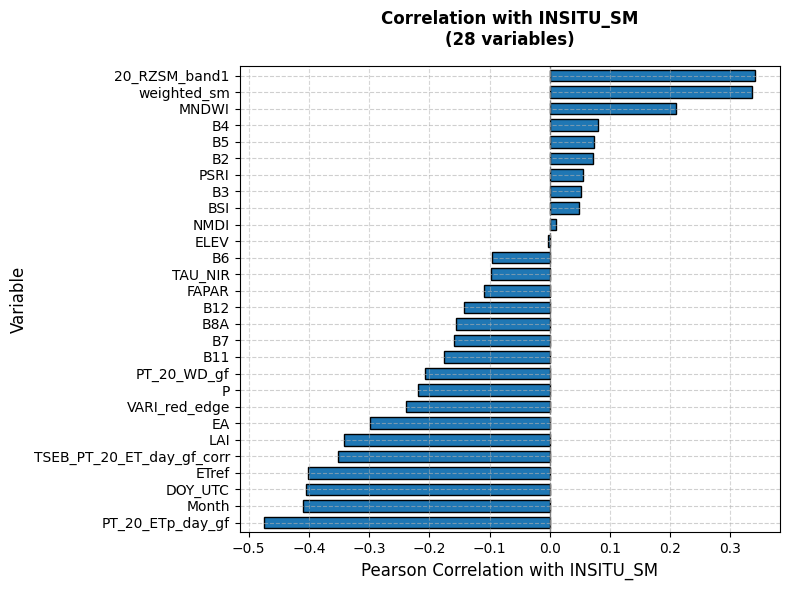

In [27]:
# we could also use a bar plot of correlations
corr_bar(numeric_data, target="INSITU_SM", figsize=(8,6))
plt.show()

# 4. Modelling

### 4.1. Baseline Performance

Before building advanced ML models, we would like to establish a baseline.  In our case, the baseline is the **weighted soil moisture**, which will be directly compared to the **in-situ SM**.  

We evaluate the baseline on three levels:

1. **Training and Test sets** – to check how well the baseline matches observed data during model development and validation.
2. **Entire dataset** – to understand the overall fidelity of the baseline product.
3. **Station level** – to assess spatial reliability -> how consistent the baseline is across different measurement stations. and Are we able to have SM that are spatially reliable across different locations.

In [28]:
# Evaluate baseline (weighted SM) performance
results = evaluate_baseline(df_valid_train, df_valid_test, target_col="INSITU_SM", baseline_col="weighted_sm")

Baseline Results for Training Set:
Train Pearson r: 0.3356
Train R²: -0.2305
Train RMSE: 14.0839
Train MAE: 11.0595

Baseline Results for Test Set:
Test Pearson r: 0.7126
Test R²: -0.4646
Test RMSE: 8.7114
Test MAE: 7.0416

Baseline Results for Full Dataset:
Overall Pearson r: 0.4665
Overall R²: -0.2204
Overall RMSE: 12.0461
Overall MAE: 9.3125



In [29]:
# Station-level 
station_results, avg_metrics = evaluate_stations(
    df_valid_train,
    station_col="Station",   
    target_col="INSITU_SM",
    pred_col="weighted_sm"
)


Station-level metrics (grouped by `Station`):
         Pearson_r         R2       RMSE        MAE
Station                                            
1.01      0.441687   0.159020   8.792065   7.018522
1.03      0.340572   0.069290  11.586701  10.190064
1.06      0.664216 -16.904628  24.525166  24.122712
1.07      0.582907  -0.155912  11.246337   9.361459
1.08      0.905615  -1.206492   5.245493   4.507887
1.09      0.574586  -4.990429  12.237776  11.108105
1.1       0.570045  -5.113743  11.830914  11.097953
2.03      0.311664  -1.826581   6.279941   5.116700
2.04      0.588194  -0.536076   5.184515   3.971002
2.05      0.436271  -1.054156   7.685093   6.207550
2.06      0.655860  -4.350651  12.189099  11.517870
2.07      0.438964  -6.636533  15.961637  15.065373
2.08      0.540662  -4.064759  19.700190  17.849709
2.09      0.052311  -1.651067  24.670489  22.529412
2.1      -0.095031  -1.128225  12.288982   9.133257
2.11      0.414731   0.056169  13.155268   9.293626
3.01      0.67535

### 4.2. ML Models for Soil Moisture (SM)

After evaluating the baseline product, we can now explore ML models, to see if we could better predict SM using the available features.  

In this example, we use the **HistGradientBoostingRegressor** from scikit-learn, which is a fast and robust gradient boosting algorithm suitable for tabular data. Any other alternatives, like tree-based models like **RandomForest**, **XGBoost**, **LightLGBM** and **CatBoost** can be used. 

In [30]:
model = HistGradientBoostingRegressor(random_state=42, max_iter=300)
model.fit(X_train, y_train.values.ravel())

,loss,'squared_error'
,quantile,None
,learning_rate,0.1
,max_iter,300
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [39]:
os.makedirs("../data/HOBE/models", exist_ok=True)
dump(model, "../data/HOBE/models/histgb_model.joblib")

['../data/HOBE/models/histgb_model.joblib']

In [31]:
trained_model = load("../data/HOBE/models/histgb_model.joblib")

In [32]:
y_pred_train = trained_model.predict(X_train)

In [33]:
train_stats = regression_metrics(y_train.values.ravel(), y_pred_train, label="Train", return_results=True)
train_stats

Train Pearson r: 0.9986
Train R²: 0.9971
Train RMSE: 0.6844
Train MAE: 0.4676



{'Pearson_r': np.float64(0.9985674757074267),
 'R2': 0.9970942441590622,
 'RMSE': np.float64(0.6844095576134034),
 'MAE': 0.4676450645147417}

In [34]:
y_pred_test = trained_model.predict(X_test)

In [35]:
test_stats = regression_metrics(y_test.values.ravel(), y_pred_test, label="Test", return_results=True)
test_stats

Test Pearson r: 0.6621
Test R²: 0.4027
Test RMSE: 5.5633
Test MAE: 4.4314



{'Pearson_r': np.float64(0.662136229531761),
 'R2': 0.4026862462184747,
 'RMSE': np.float64(5.563334136001877),
 'MAE': 4.431420141080475}

In [36]:
r, r2, rmse, mae = test_stats.get('Pearson_r'), test_stats.get('R2'), test_stats.get('RMSE'), test_stats.get('MAE')

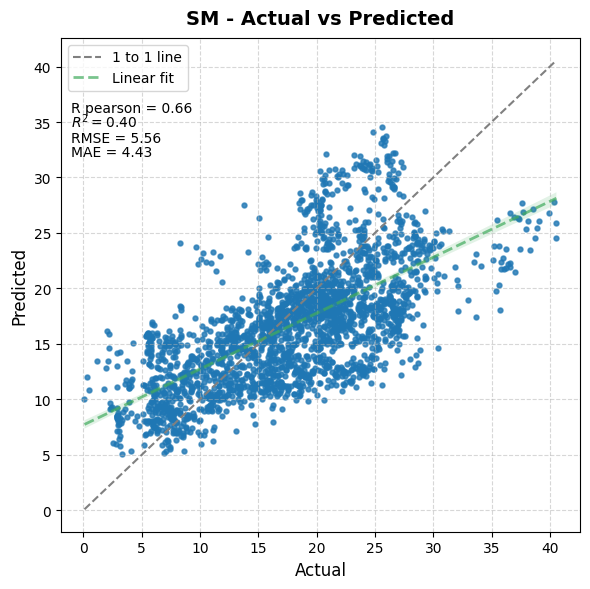

In [37]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test.values.ravel(), y_pred_test, alpha=0.6, s=14)
plt.plot(
    [min(y_test.values.ravel()), max(y_test.values.ravel())], 
    [min(y_test.values.ravel()), max(y_test.values.ravel())], 
    color='grey', linestyle='--',label='1 to 1 line'
)
sns.regplot(
    x=y_test.values.ravel(), 
    y=y_pred_test, 
    line_kws={"color": "#41ab5d", "alpha": 0.7, "lw": 2, "linestyle": "dashed", "label": "Linear fit"},
    scatter_kws={'s': 7, 'alpha': 0.5}
)
base_y = 0.85  
step = 0.03   

plt.xlabel("Actual", fontsize=12)
plt.ylabel("Predicted", fontsize=12)
plt.title("SM - Actual vs Predicted", fontsize=14, weight='bold', pad=10)
plt.annotate(f'R pearson = {r:.2f}', xy=(0.02, base_y), xycoords='axes fraction', color='black')
plt.annotate(f'$R^2 = {r2:.2f}$', xy=(0.02, base_y - step), xycoords='axes fraction', color='black')
plt.annotate(f'RMSE = {rmse:.2f}', xy=(0.02, base_y - 2 * step), xycoords='axes fraction', color='black')
plt.annotate(f'MAE = {mae:.2f}', xy=(0.02, base_y - 3 * step), xycoords='axes fraction', color='black')
plt.legend(loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 4.3. Spatial Reliability  of the model

In [38]:
results_df, avg_metrics = loso_cv_ml(
    df_valid_train,
    features=to_keep,
    target="INSITU_SM",
    group_col="Station",
    model=HistGradientBoostingRegressor(random_state=42, max_iter=300)
)

print(results_df)
print("\nAverage metrics across stations:")
print(avg_metrics)

   Station  Pearson_r         R2       RMSE        MAE
0     1.01   0.773153   0.043559   9.376202   7.738310
1     1.03   0.861729  -0.978895  16.895225  15.206213
2     1.06   0.806942 -18.823129  25.805686  21.854090
3     1.07   0.836171   0.509592   7.325332   6.633171
4     1.08   0.936794   0.407987   2.717071   2.206354
5     1.09   0.670131  -4.029002  11.212809   9.444083
6      1.1   0.682309 -37.467486  29.676426  27.013068
7     2.03   0.633509  -0.495313   4.567630   3.858106
8     2.04   0.722532  -0.764939   5.557335   4.719493
9     2.05   0.757294   0.434416   4.032562   3.147905
10    2.06   0.827931  -1.980987   9.098051   8.156090
11    2.07   0.504851  -1.650675   9.403889   8.541058
12    2.08   0.438023   0.111545   8.251043   6.061430
13    2.09   0.842894  -1.829140  25.485585  23.928908
14     2.1   0.854634   0.666754   4.862836   4.279417
15    2.11   0.669802  -2.441740  25.121270  22.746461
16    3.01   0.742845  -0.342433   9.515504   8.099473
17    3.02

In [39]:
station_results.mean()

Pearson_r     0.498929
R2           -3.377272
RMSE         12.817129
MAE          11.294582
dtype: float64

In [40]:
results_df[~results_df['Station'].isin(["1.1"])].drop('Station', axis=1).mean()

Pearson_r    0.759631
R2          -1.389172
RMSE         9.794757
MAE          8.500662
dtype: float64

In [41]:
station_results[~station_results.index.isin(["1.1"])].mean()

Pearson_r     0.495696
R2           -3.298341
RMSE         12.861957
MAE          11.303519
dtype: float64

> Let try to examine the reasons why we might have poor spatial generalization. One why to do this is to examine the distrubition of the data across different folds during the Leave One Station Out spatial cross valiadtion.

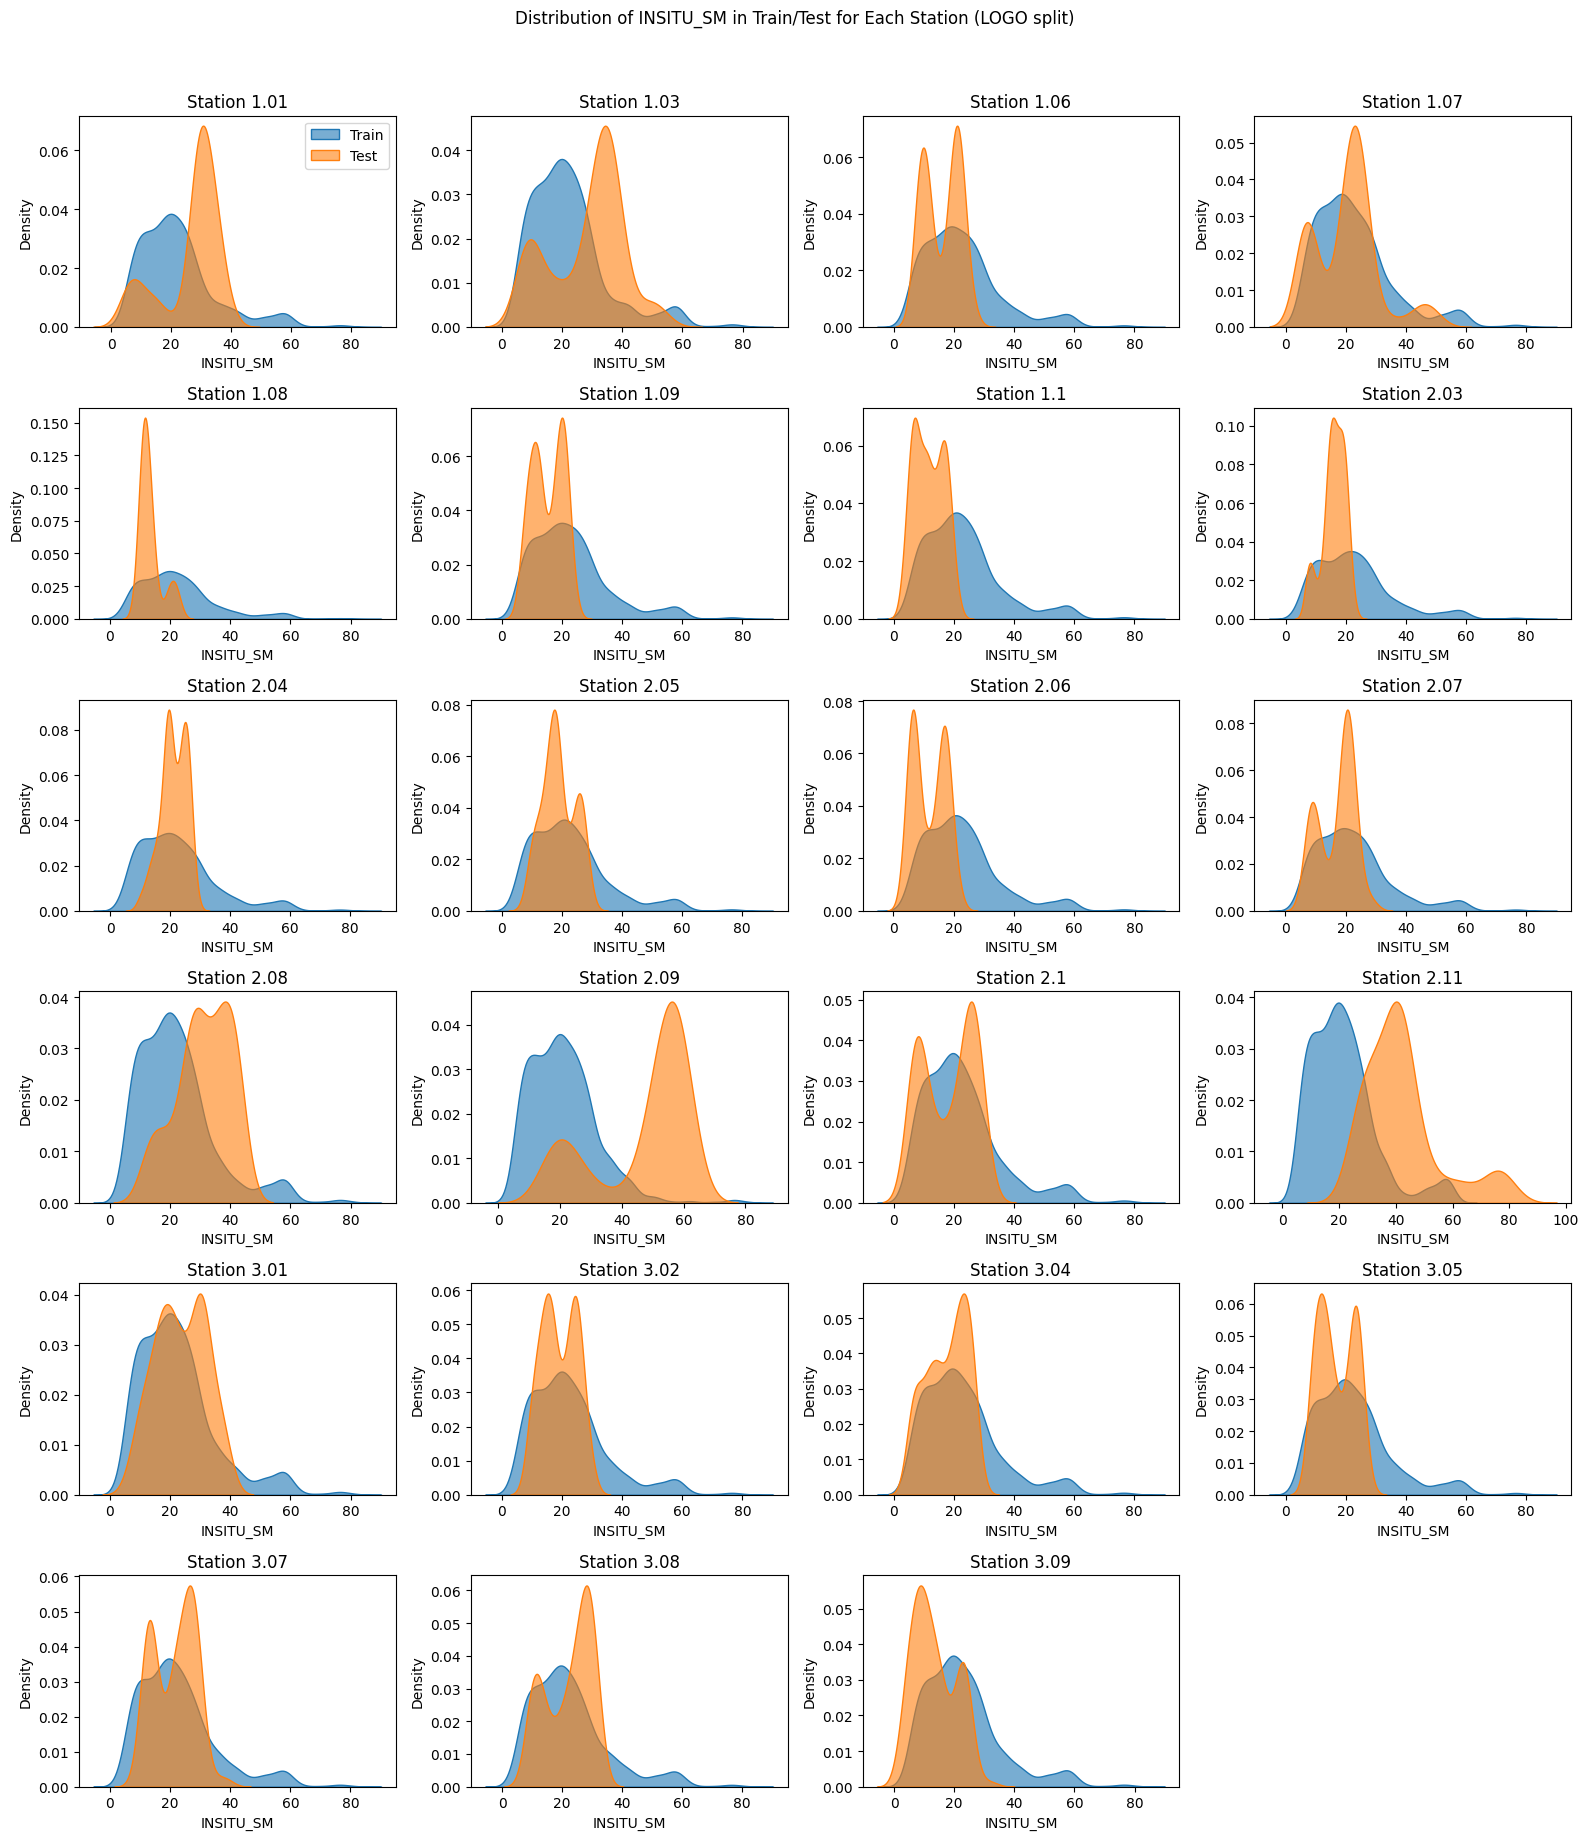

In [42]:
plot_loso_distributions(
    df=df_valid_train,
    target="INSITU_SM",
    group_col="Station",
    cols=4
)

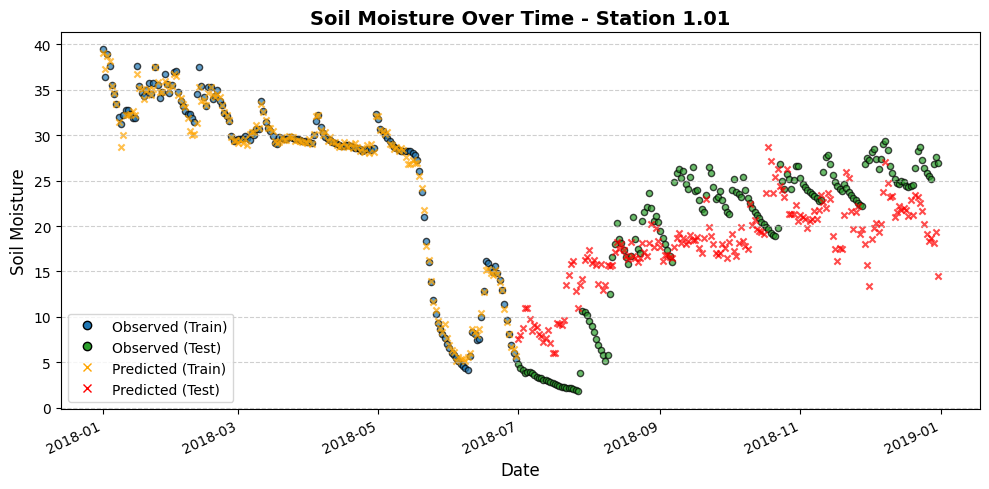

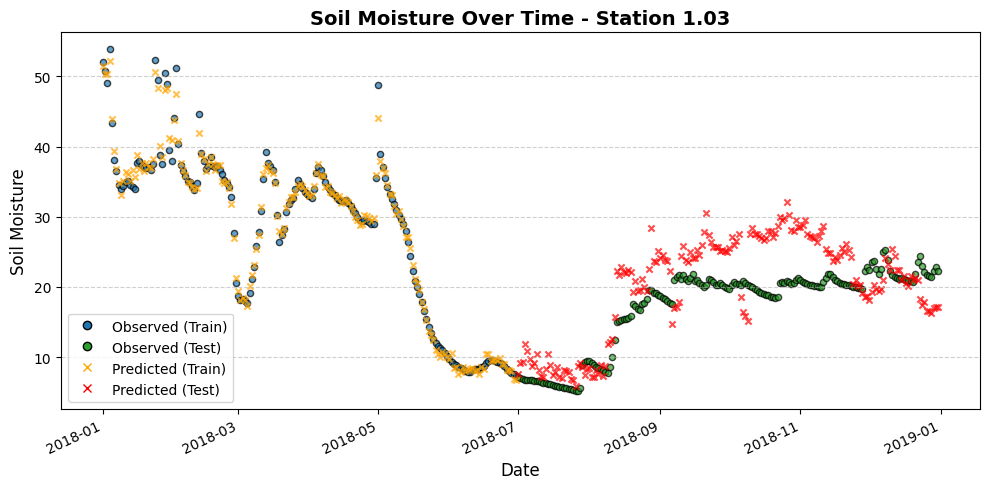

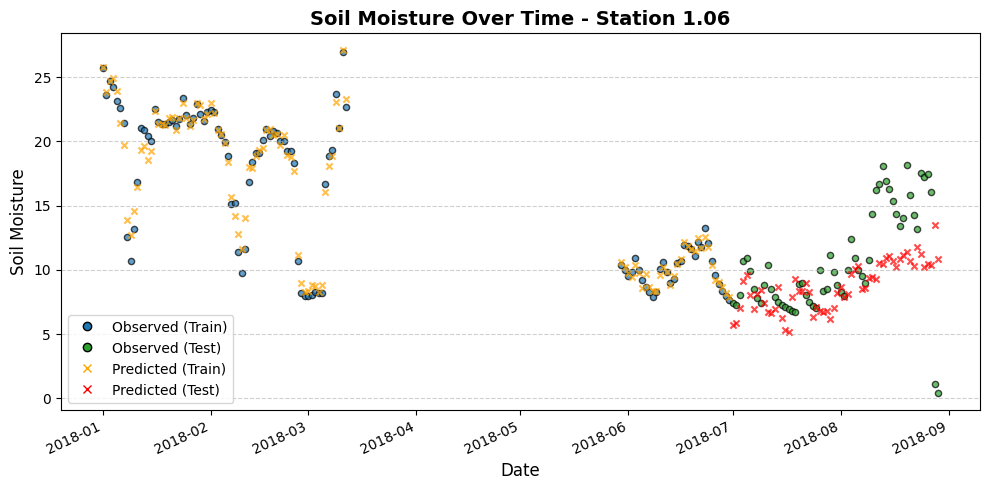

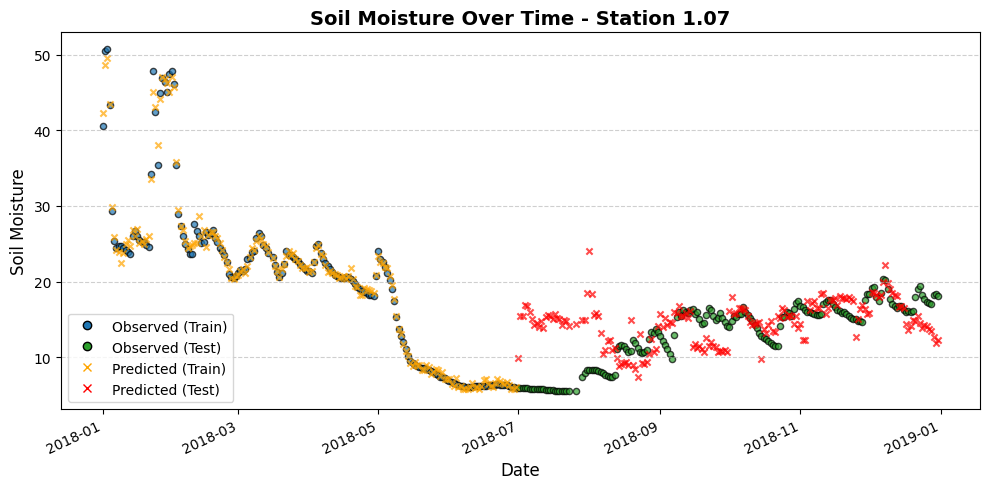

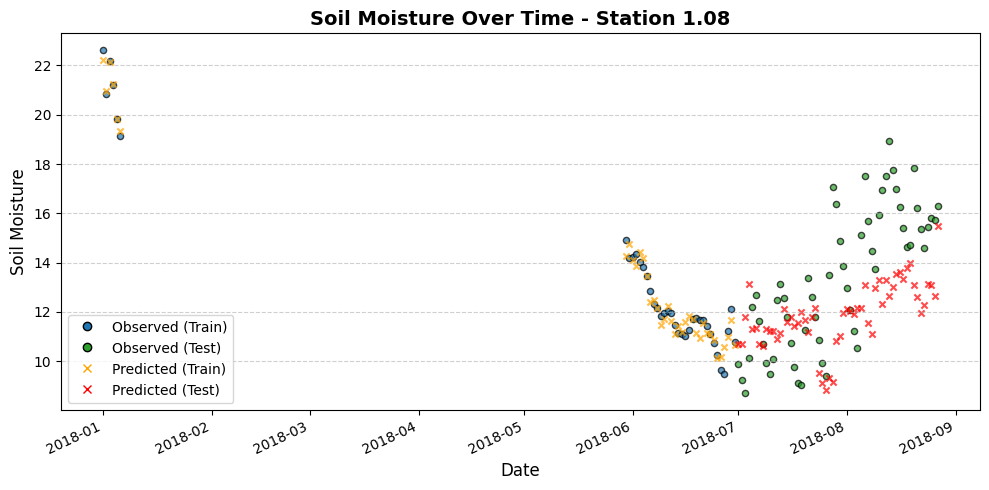

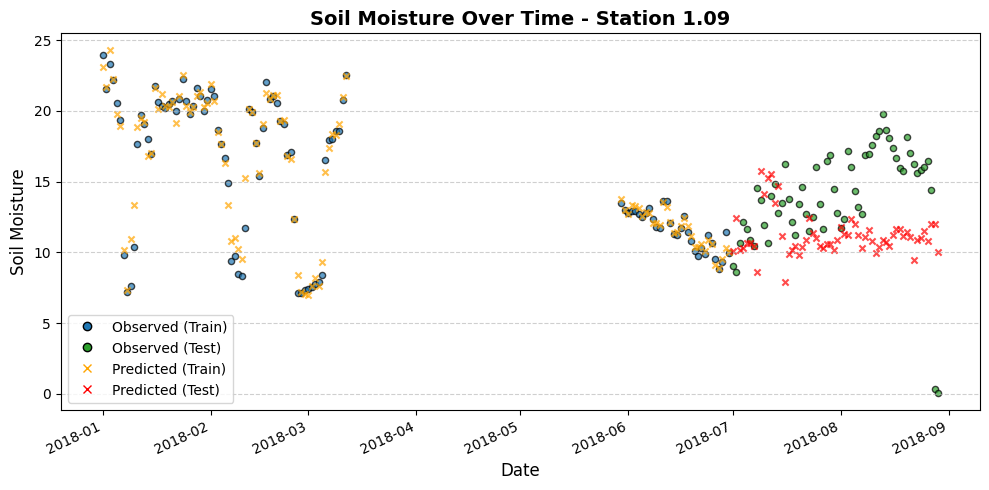

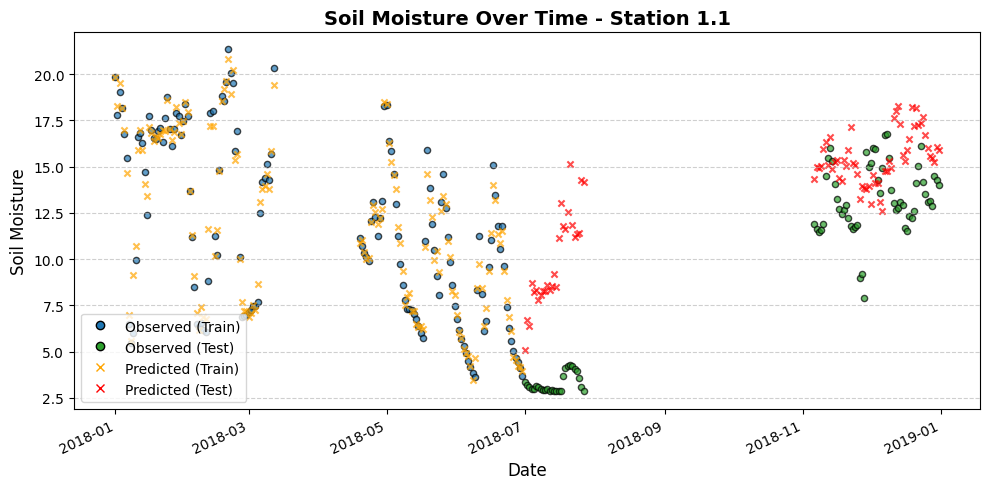

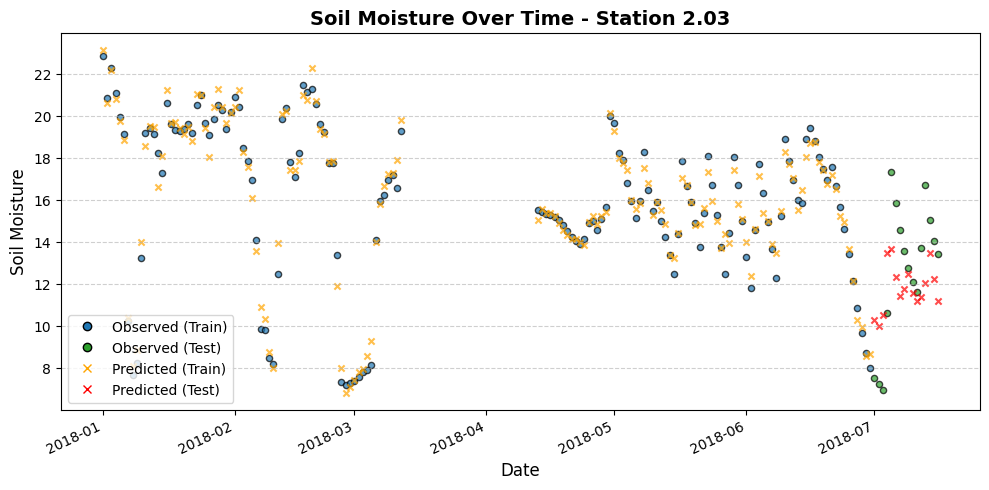

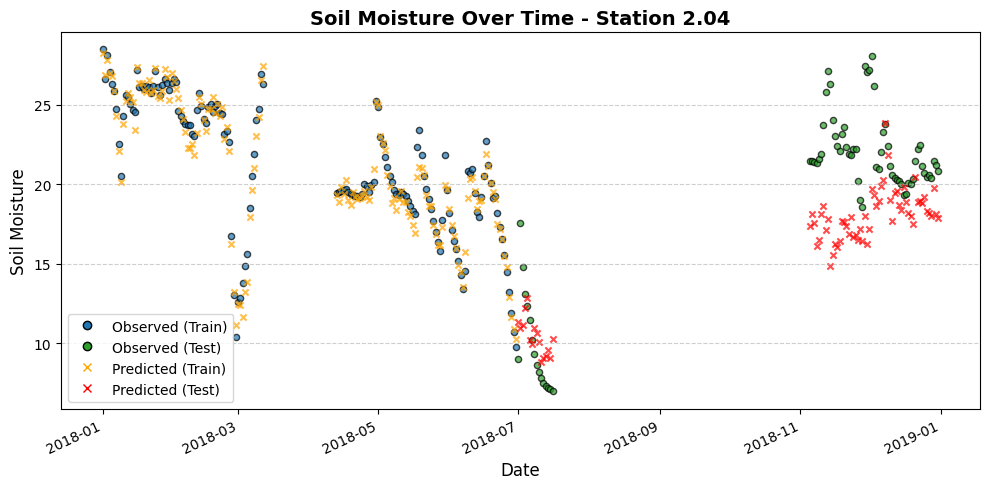

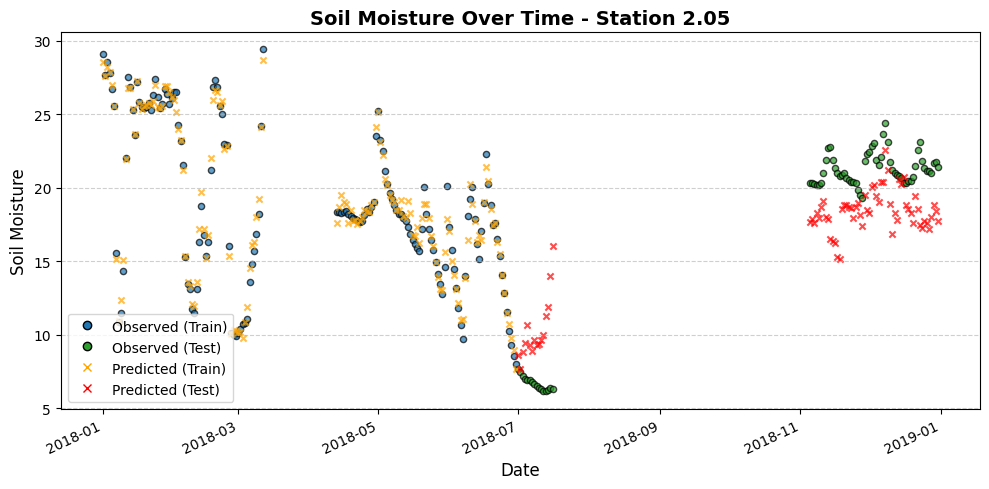

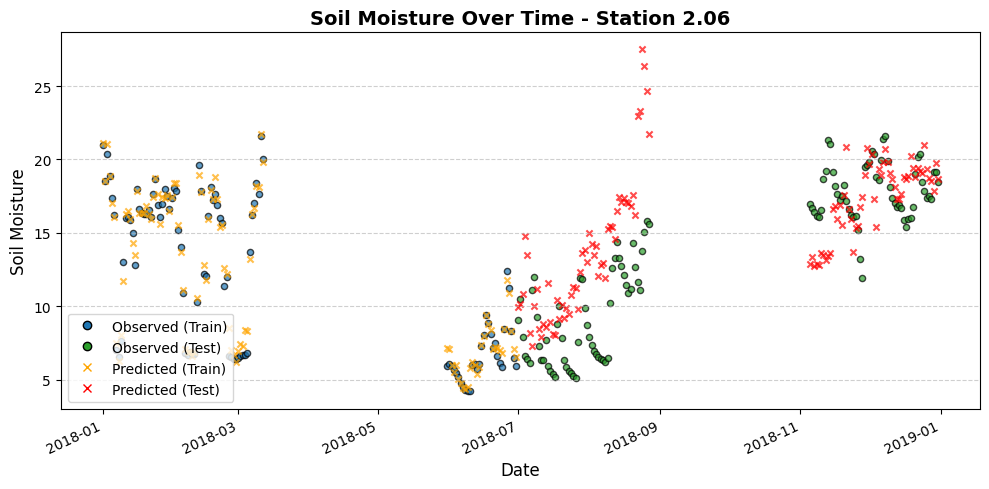

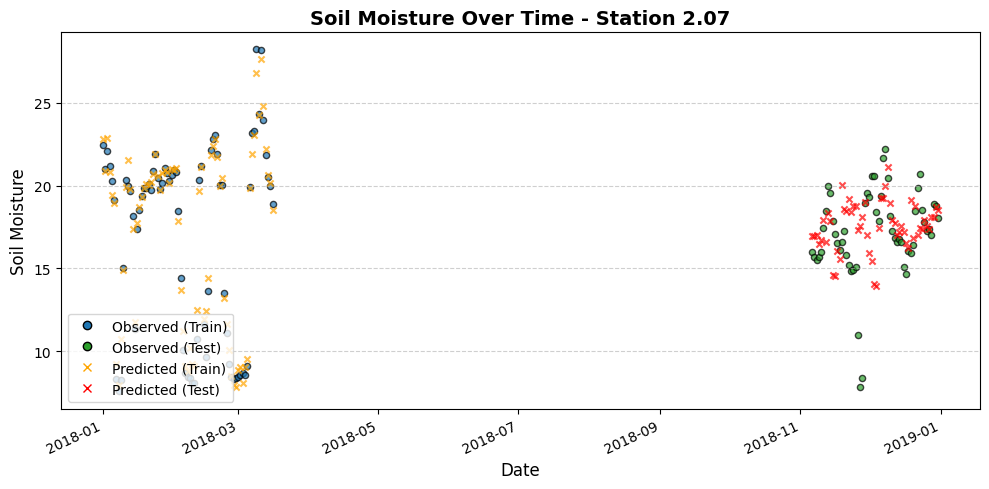

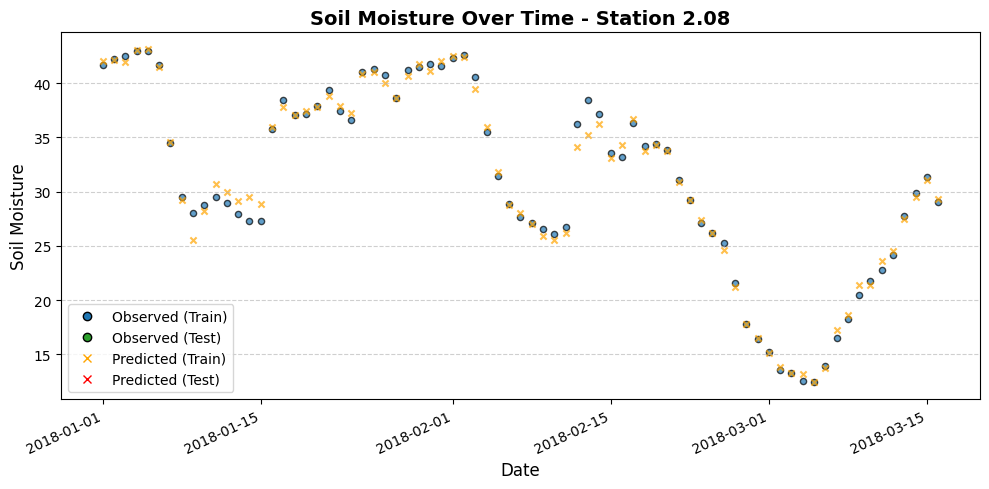

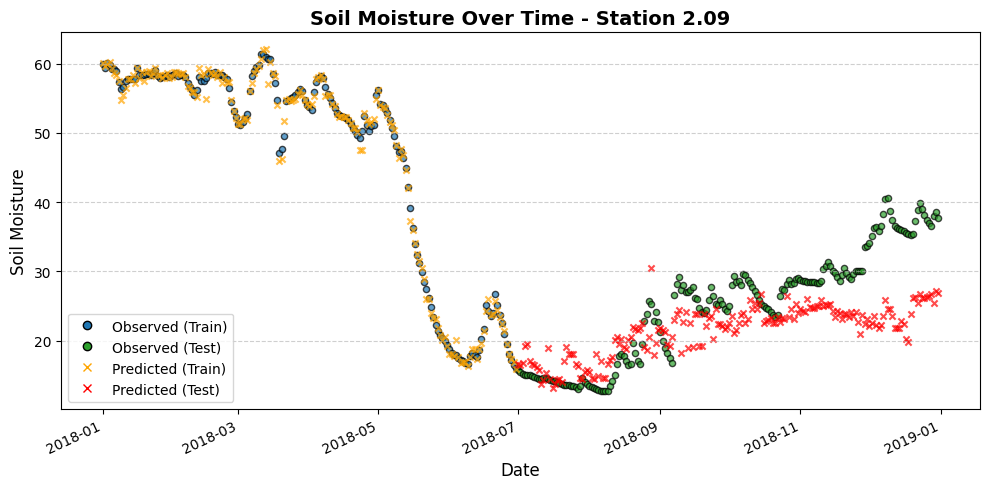

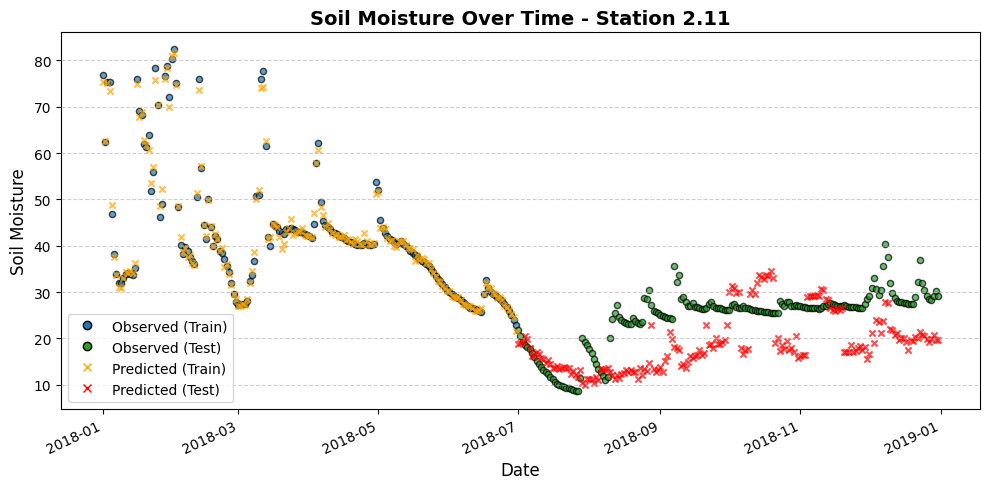

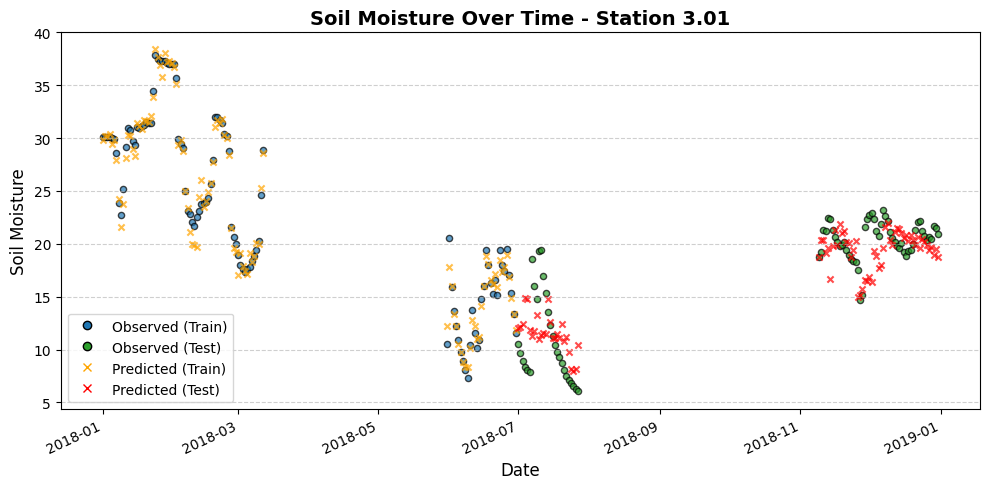

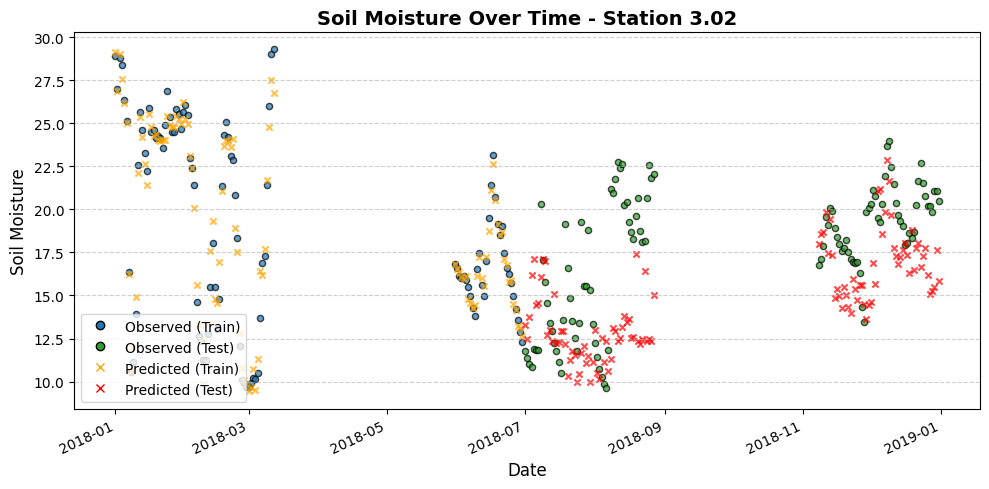

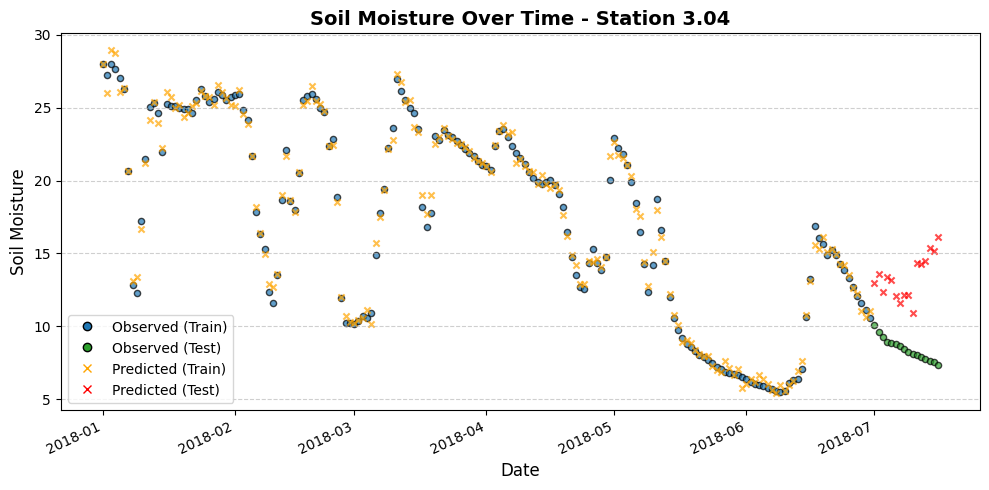

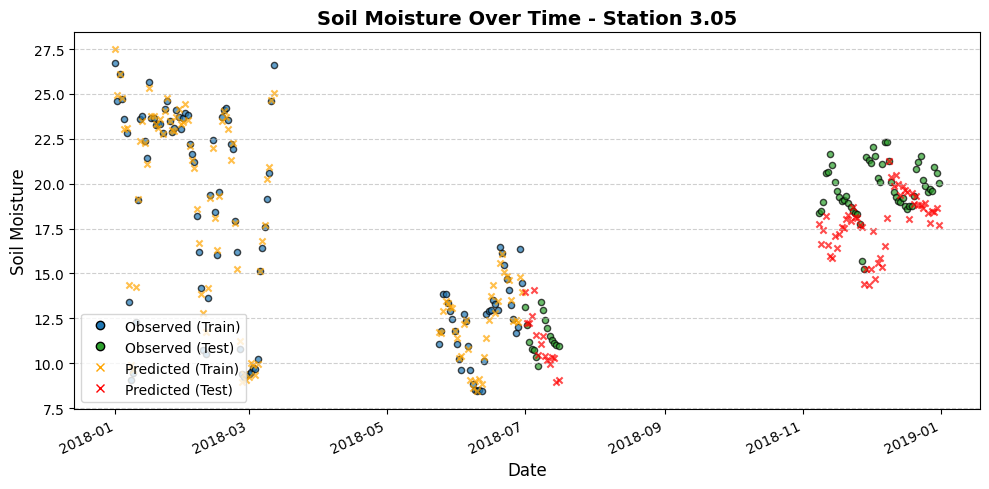

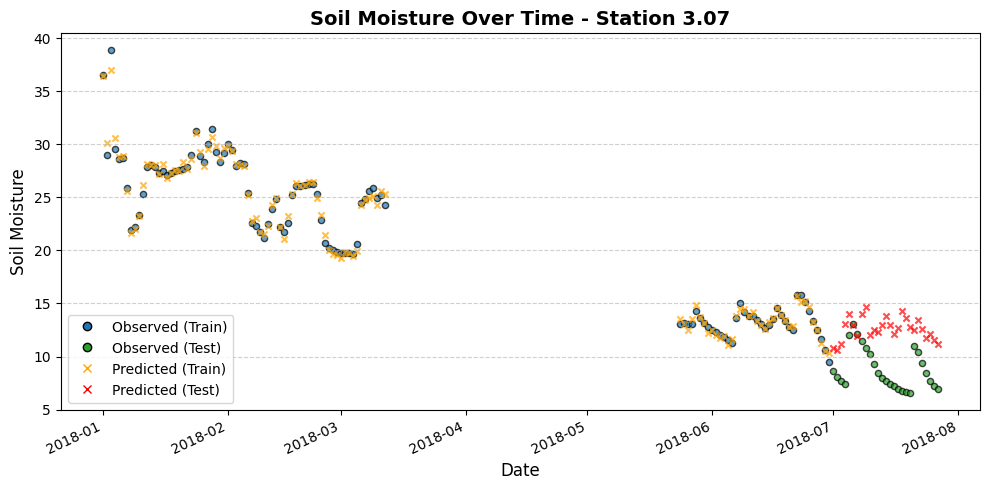

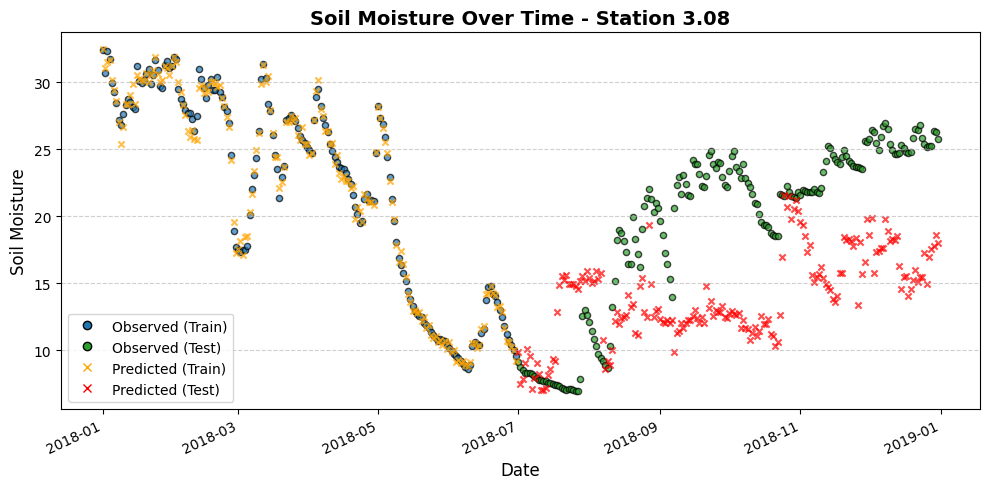

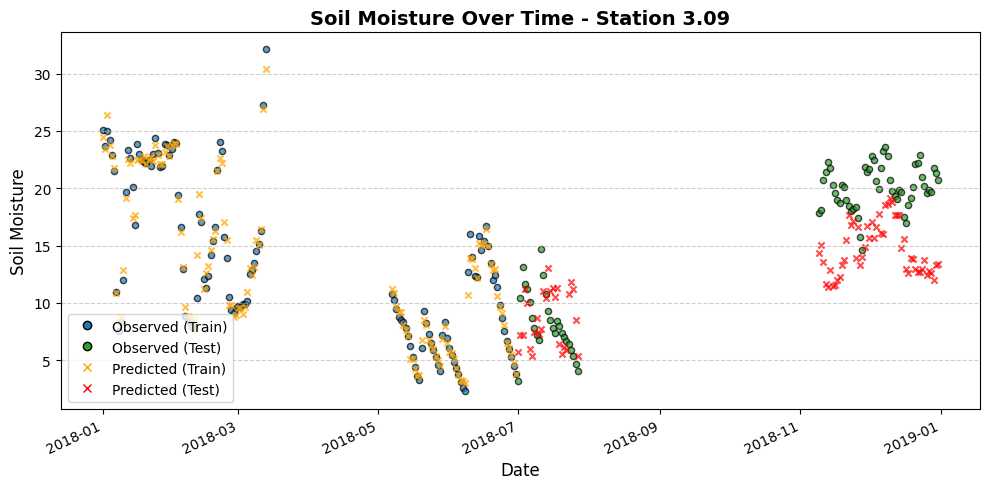

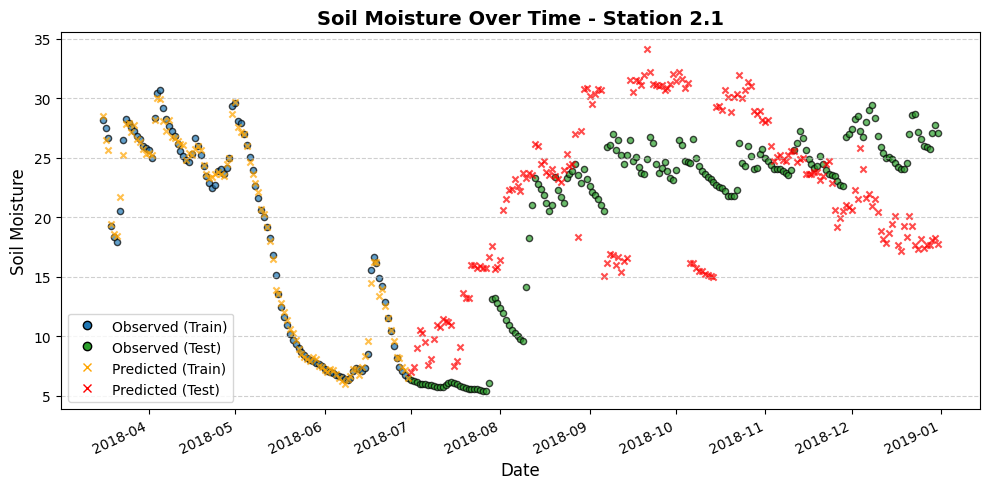

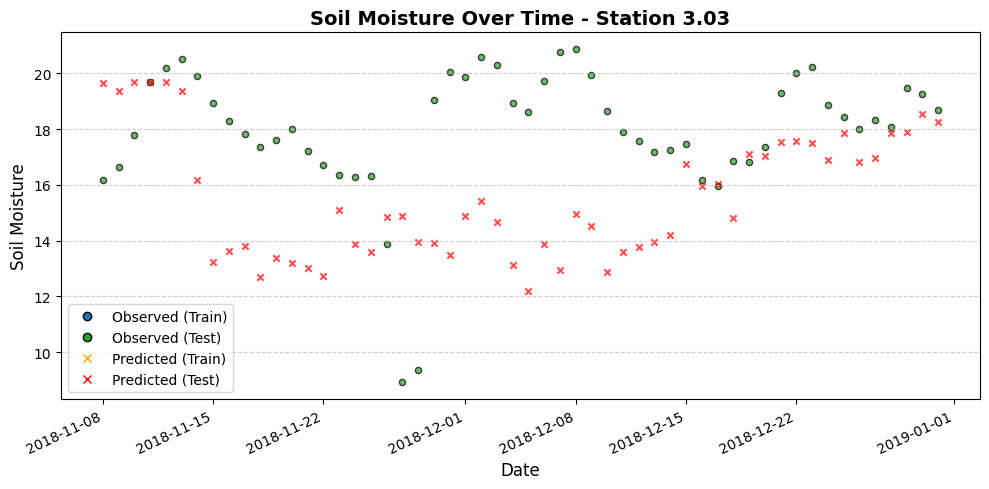

In [43]:
plot_predictions_by_station(
    df_train=df_valid_train[to_keep + ["Date", "Station", "INSITU_SM"]],
    df_test=df_valid_test[to_keep + ["Date", "Station", "INSITU_SM"]],
    model=trained_model,
    features=to_keep,
    target_col="INSITU_SM",
    date_col="Date",
    station_col="Station"
)

# 5. Features Importance

- Reference: https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html#feature-importances-with-a-forest-of-trees

In [44]:
from sklearn.inspection import permutation_importance

In [45]:
importance_results = permutation_importance(
    trained_model, X_train, y_train,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [46]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance Mean': importance_results.importances_mean,
    'Importance Std': importance_results.importances_std
}).sort_values(by='Importance Mean', ascending=False)
importance_df

,Feature,Importance Mean,Importance Std
14,ELEV,0.646018,0.012211
21,weighted_sm,0.413288,0.013166
27,DOY_UTC,0.359697,0.014317
10,NMDI,0.038116,0.000877
18,EA,0.036247,0.000554
26,Month,0.024953,0.000455
11,PSRI,0.023327,0.001393
16,LAI,0.021753,0.000516
19,P,0.014434,0.001532
6,B8A,0.013408,0.000512


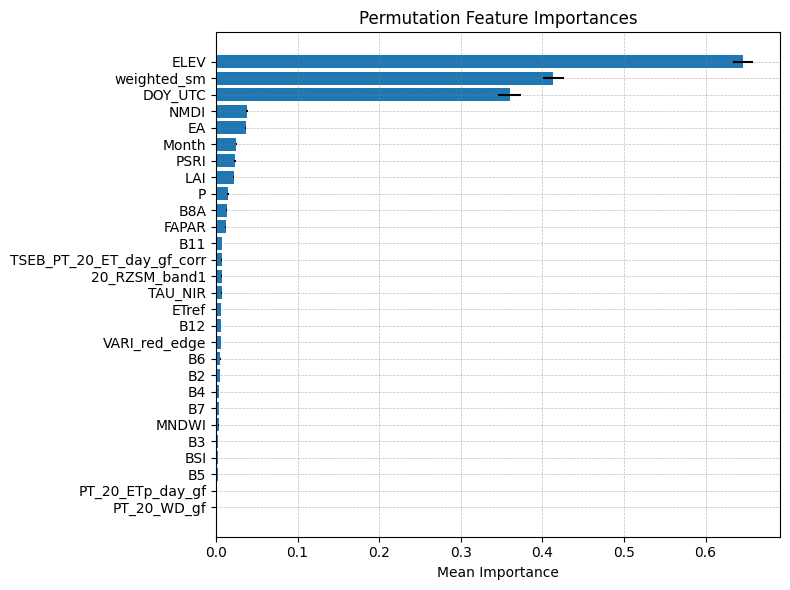

In [47]:
plt.figure(figsize=(8, 6))
plt.barh(importance_df['Feature'], importance_df['Importance Mean'], xerr=importance_df['Importance Std'])
plt.gca().invert_yaxis()
plt.xlabel('Mean Importance')
plt.title('Permutation Feature Importances')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

# 5. Spatial Prediction

- Once we trained and we validated our model, now we are ready to make spatial predictions using our predictor variables stored as NetCDF file.

In [48]:
# we stored the dataset with all the variables required to run the model and generate spatial predictions 
ds = xr.open_dataset("../data/HOBE/dataset/features_dataset_20180701.nc")

In [49]:
ds

<xarray.Dataset> Size: 917MB
Dimensions:                          (time: 1, y: 1022, x: 1495)
Coordinates:
  * time                             (time) datetime64[ns] 8B 2018-07-01
  * y                                (y) float64 8kB 56.09 56.09 ... 55.86 55.86
  * x                                (x) float64 12kB 8.813 8.813 ... 9.157
Data variables: (12/76)
    20_irri_calc                     (time, y, x) float64 12MB ...
    20_RZD                           (time, y, x) float64 12MB ...
    20_RZSM_band1                    (time, y, x) float64 12MB ...
    20_RZSM_band2                    (time, y, x) float64 12MB ...
    20_RZSM_band3                    (time, y, x) float64 12MB ...
    DOY_UTC                          (time, y, x) float64 12MB ...
    ...                               ...
    TSEB_PT_20_LE_partition_gf_corr  (time, y, x) float64 12MB ...
    U                                (time, y, x) float64 12MB ...
    VZA                              (time, y, x) float64 12MB ...
    W_C                              (time, y, x) float64 12MB ...
    X_LAD                            (time, y, x) float64 12MB ...
    spatial_ref                      int32 4B ...

In [50]:
SM_S2_BANDS

{'REFL_band1': 'B2',
 'REFL_band2': 'B3',
 'REFL_band3': 'B4',
 'REFL_band4': 'B5',
 'REFL_band5': 'B6',
 'REFL_band6': 'B7',
 'REFL_band7': 'B8A',
 'REFL_band8': 'B11',
 'REFL_band9': 'B12'}

In [51]:
ds = ds.rename(SM_S2_BANDS)

# add derived variables
ds['weighted_sm'] = (ds['20_RZSM_band1'] + ds['20_RZSM_band2']) / 2

ds['NDVI'] = (ds["B8A"] - ds["B4"]) / (ds["B8A"] + ds["B4"])
ds['MNDWI'] = (ds["B3"] - ds["B11"]) / (ds["B3"] + ds["B11"])
ds['NMDI'] = (ds["B8A"] - (ds["B11"] - ds["B12"])) / (ds["B8A"] + (ds["B11"] - ds["B12"]))
ds["PSRI"] = (ds["B4"] - ds["B2"]) / ds["B8A"]
ds["VARI_red_edge"] = (ds["B5"] - (1.7 * ds["B4"]) + (0.7 * ds["B2"])) / (ds["B5"] + (2.3 * ds["B4"]) - (1.3 * ds["B2"]))
ds["BSI"] = ((ds["B11"] + ds["B4"]) - (ds["B8A"] + ds["B2"])) / ((ds["B11"] + ds["B4"]) + (ds["B8A"] + ds["B2"]))

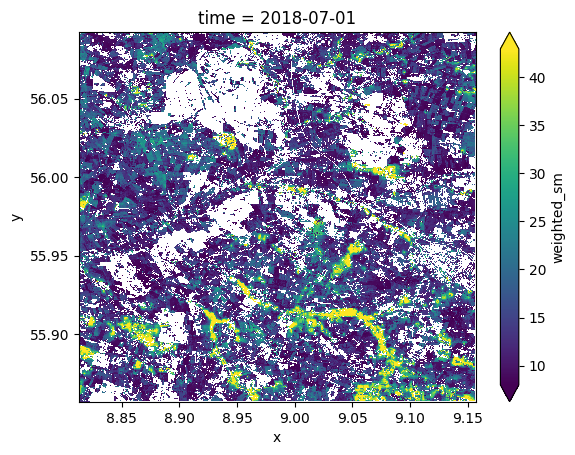

In [52]:
ds["weighted_sm"].sel(time="2018-07-01").plot(robust=True)

In [53]:
# check which variables are missing
[var for var in to_keep if var not in ds.data_vars]

['Month']

In [54]:
# lets add a dummy variable for month
month = 7  
ds["Month"] = xr.DataArray(np.full(ds["B2"].shape, month), dims=ds["B2"].dims)

In [55]:
# make sure to set the crs if not already set
ds.rio.write_crs("EPSG:4326", inplace=True)
ds.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [56]:
da = ds.sel(time="2018-07-01")[to_keep].to_array(dim="band")

- Now we are ready to make a spatial prediction across the entire dataset to get predicted SM.

In [57]:
assert list(ds[to_keep].data_vars) == to_keep

da_pred = xr_predict(
    da=da,
    model=trained_model,
    feature_names=to_keep,
    band_dim="band",    
    chunk_size=1012*1012,
    pred_name="SM_preds",
).rio.write_crs("EPSG:4326", inplace=True)

Predicting: 100%|██████████| 2/2 [00:09<00:00,  4.51s/it]


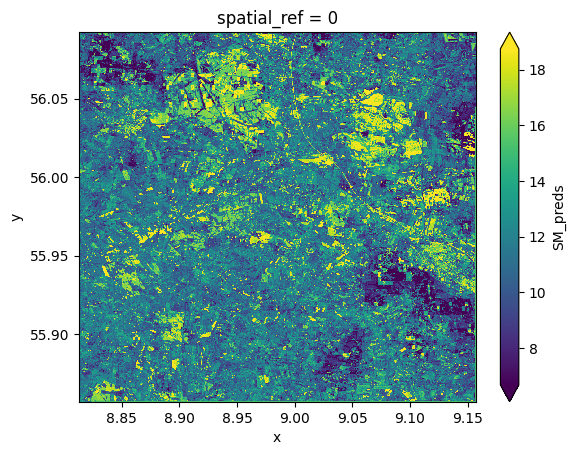

In [58]:
da_pred.plot(robust=True)

In [ ]:
os.makedirs("../data/HOBE/preds", exist_ok=True)
da_pred.rio.to_raster("../data/HOBE/preds/SM_predictions_20180701.tif")